In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import afterglowpy as grb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import math
import sys
from itertools import chain
import math
from astropy.coordinates import SkyCoord

In [3]:
sys.path.append('../orphans')

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import pickling as pkg
from tools import ObsTime, mag_to_flux, flux_to_mag, pseudo_obs_with_points
from tools import get_wl_and_nu_band
from correlations import minimal_magnitude, peak_time, duration_between_first_and_peak, rate, color, heatmap
from plotting_lc import plot_pseudo_obs, plot_simulation

## Generate and save all configurations

- Use of realistic enough distributions for the parameters ($E_0$, $n_0$, $z$, $\theta_c$, $\theta_w$, $\theta_{obs}$),
- Configurations saved in a Pickle file.

**Output :** `configs_<thetaCore>_<N>.pkl` or `<filename>_<thetaCore>.pkl` (if a different file name is chosen) where `<thetaCore>` is `005` or `015` and `<N>` is the number of simulated GRBs.

In [110]:
N = 1000           # number of simulated GRBs
thetaCore = '015'  # thetaCore 
jetType = 'PL'     # type of structured jet

In [111]:
#name = f'../data/simulations/configs_{N}'
name = f'../data/simulations/configs'
pkg.generate_configs(N, popType='boosted', filename=name)

  0%|          | 0/1000 [00:00<?, ?it/s]

## Calculate and save results of simulations

- Simulation of a population of short GRBs thanks to the saved configurations, 
- Calculation of some results ($t_{obs}$, $mag_{min}$, the axis, the observability and the flux in $\gamma$ photons) from these simulations,
- Results saved in another Pickle file.

**Output :** `simulations_<jetType>_<thetaCore>_<N>.pkl` or `<filename>.pkl` where `<jetType>` = `TH` (Top-Hat), `G` (Gaussian) or `PL` (**Power-Law by default**).

In [112]:
t = np.geomspace(1.0e2, 1.0e9, 300)   # time for which the afterglow light curve is calculated

#name_config = f'../data/simulations/configs_{thetaCore}_{N}.pkl'
#name_simu = f'../data/simulations/simulations_{jetType}_{thetaCore}_{N}.pkl'

name_config = f'../data/simulations/configs_{thetaCore}_{N}'
name_simu = f'../data/simulations/simulations_{jetType}_{thetaCore}_{N}'

pkg.calculate_results(N, t, thetaCore, filename_in=name_config, filename_out=name_simu)

  0%|          | 0/1000 [00:00<?, ?it/s]

## Open the results of the simulations

**Units :** 
- $t_{obs}$ in days,
- $F_\gamma$ in photons/cm$^2$/s.

In [113]:
results = pkg.open_results(N, thetaCore, filename=name_simu)

In [114]:
results

,jetType,config,time,lc,t_obs,mag_min,axis,observable,F_gamma
0,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[7.469856964741919e-31, 1.0604404583282513e-30...",2813.463902,20.629247,off,> 7 days,4.376360e-07
1,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[4.448092689759053e-37, 6.314633054084873e-37,...",4404.369287,22.178852,off,> 7 days,1.048928e-07
2,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[1.417017734604197e-32, 2.0116349839741108e-32...",779.981898,22.449822,off,> 7 days,8.176077e-08
3,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[1.7756029494442393e-37, 2.5206962721178322e-3...",0.000000,27.094552,off,no,1.150591e-09
4,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[2.606956221828482e-43, 3.700903820106818e-43,...",0.000000,25.316940,off,no,5.835728e-09
...,...,...,...,...,...,...,...,...,...
995,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[8.466634310802909e-39, 1.2019461212667985e-38...",6966.557056,22.560146,off,> 7 days,7.386534e-08
996,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[1.6547366211654511e-37, 2.349106065330708e-37...",0.000000,26.418213,off,no,2.115419e-09
997,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[5.37831345333627e-39, 7.635193254861193e-39, ...",0.000000,24.913527,off,no,8.456378e-09
998,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[5.8051003817551885e-24, 8.241059737265125e-24...",180.116876,19.621629,off,> 7 days,1.107121e-06


In [115]:
# numbre of afterglows observed off-axis for at least 7 days

observable_oa = results[(results['axis'] == 'off') & (results['t_obs'] > 7.)]
observable_oa

,jetType,config,time,lc,t_obs,mag_min,axis,observable,F_gamma
0,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[7.469856964741919e-31, 1.0604404583282513e-30...",2813.463902,20.629247,off,> 7 days,4.376360e-07
1,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[4.448092689759053e-37, 6.314633054084873e-37,...",4404.369287,22.178852,off,> 7 days,1.048928e-07
2,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[1.417017734604197e-32, 2.0116349839741108e-32...",779.981898,22.449822,off,> 7 days,8.176077e-08
5,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[2.06726530567526e-39, 2.9347425856389083e-39,...",487.214622,24.423734,off,> 7 days,1.327951e-08
6,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[6.3258004595505565e-31, 8.98025015631098e-31,...",1623.991608,20.434182,off,> 7 days,7.370735e-07
...,...,...,...,...,...,...,...,...,...
992,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[5.913056350669175e-35, 8.394379460654333e-35,...",5550.587390,20.971744,off,> 7 days,3.195594e-07
993,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[2.691170595123053e-20, 3.820458063859403e-20,...",9845.434950,13.826265,off,> 7 days,2.303180e-04
994,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[1.1459230898517813e-35, 1.6267817998875417e-3...",1863.821590,23.031814,off,> 7 days,4.787063e-08
995,PowerLaw,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[0.0011574074074074073, 0.0012215116933293102,...","[8.466634310802909e-39, 1.2019461212667985e-38...",6966.557056,22.560146,off,> 7 days,7.386534e-08


## Plot the simulated light curves

**Units :** 
- Time in days
- Flux in mJy.

In [ ]:
nu = np.empty(t.shape)
nu[:] = 5.0e14   # frequency in Hz

for t, fnu in zip(observable_oa['time'], observable_oa['lc']):
    
    plot_simulation(t, fnu)

## Generate and save pseudo-observations

Simulation of a pseudo-observations of population of short GRBs thanks to the `rubin_sim` package.

**Output :** `pseudo_obs_<jetType>_<thetaCore>_<N>.pkl` or `<filename>.pkl`.

In [117]:
rubin_sim_data = '/home/masson/rubin_sim_data'   # directory where are saved the rubin_sim data
path_dustmaps = '/home/masson/Documents/galactic_extinction/schlafly_dust_factor.csv'   # directory where are saved the dust factor table

#name_pseudo_obs = f'../data/pseudo_obs/pseudo_obs_{jetType}_{thetaCore}_{N}.pkl'
name_pseudo_obs = f'../data/pseudo_obs/pseudo_obs_{jetType}_{thetaCore}_{N}'
pkg.generate_pseudo_obs(N, thetaCore, path_data=rubin_sim_data, path_dustmaps=path_dustmaps, 
                        filename_in=name_simu, filename_out=name_pseudo_obs)

/home/masson/rubin_sim_data/sim_baseline/baseline_v2.1_10yrs.db


  0%|          | 0/720 [00:00<?, ?it/s]

In [118]:
#file_open = open(name_pseudo_obs, 'rb')
#file_open = open(f'../../Documents/config/lc_configs_PL_100000.pkl', 'rb')
file_open = open(f'../data/pseudo_obs/pseudo_obs_{jetType}_{thetaCore}_{N}.pkl', 'rb')
pseudo_obs = pickle.load(file_open)
file_open.close()

In [119]:
#file_open = open(name_simu, 'rb')
file_open = open(f'../data/simulations/simulations_{jetType}_{thetaCore}_{N}.pkl', 'rb')
simu = pickle.load(file_open)
file_open.close()

In [120]:
# keep only GRBs in the field of view of LSST
lc_obs = [pseudo_obs[i] for i in range(len(pseudo_obs)) if pseudo_obs[i] != 0]

In [121]:
lc_with_pts = pseudo_obs_with_points(pseudo_obs)

In [122]:
print('There are %i orphan afterglow(s) with at least one observable point by Rubin/LSST.' %len(lc_with_pts))

There are 27 orphan afterglow(s) with at least one observable point by Rubin/LSST.


In [123]:
df = pd.DataFrame(lc_with_pts)

In [129]:
df.iloc[9]

config       {'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...
grb_time                               2026-09-07T04:14:08.534
grb_coord               09h28m14.70777122s -65d40m26.91682654s
time         [61369.347366599046, 61369.34778326571, 61369....
mags         [21.669214882078588, 21.669223127216018, 21.66...
filt         [r, r, r, r, m, g, orange, g, orange, orange, ...
mags_lim     [22.92142491034501, 22.913629861306553, 22.871...
mags_err     [0.046190289703451244, 0.046504208400266527, 0...
Name: 9, dtype: object

## Plotting pseudo-observations

Plot of the pseudo-observed light curves of the orphan afterglows from a population of short GRBs.

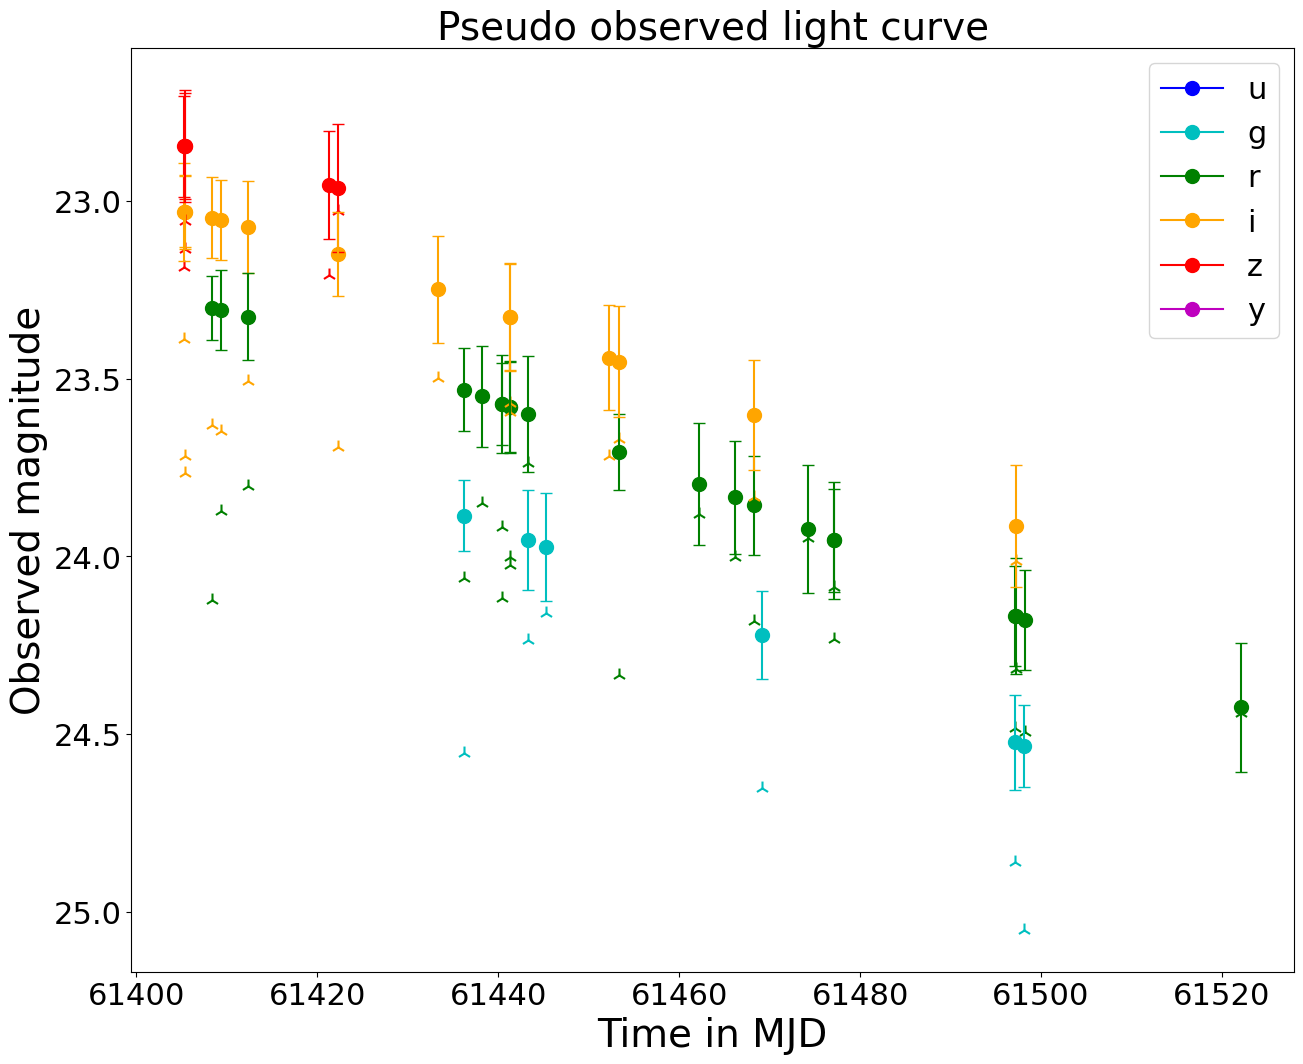

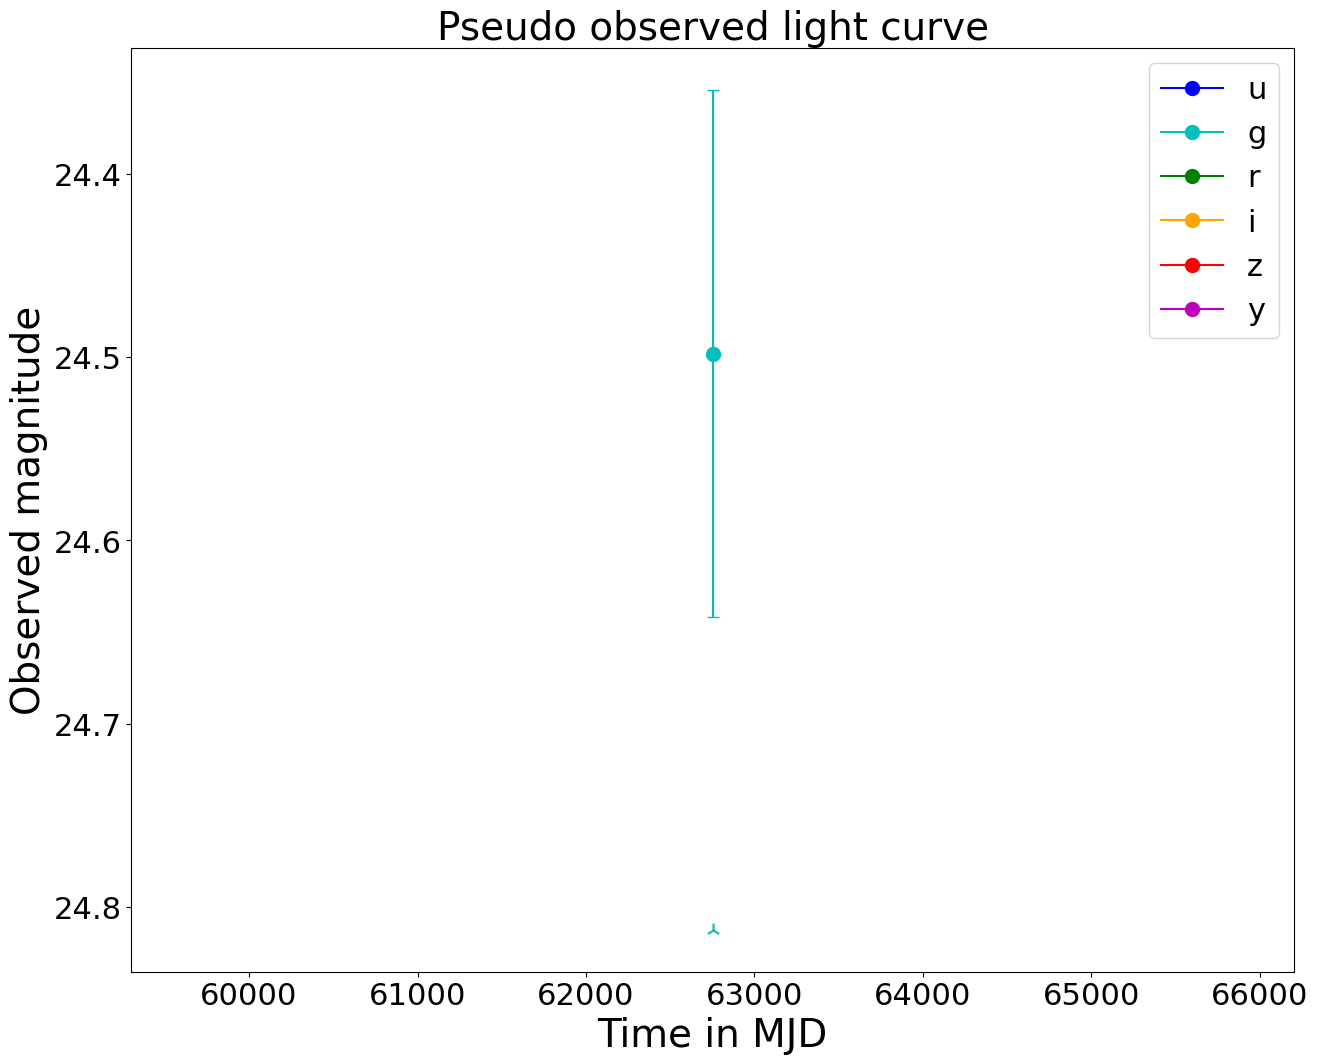

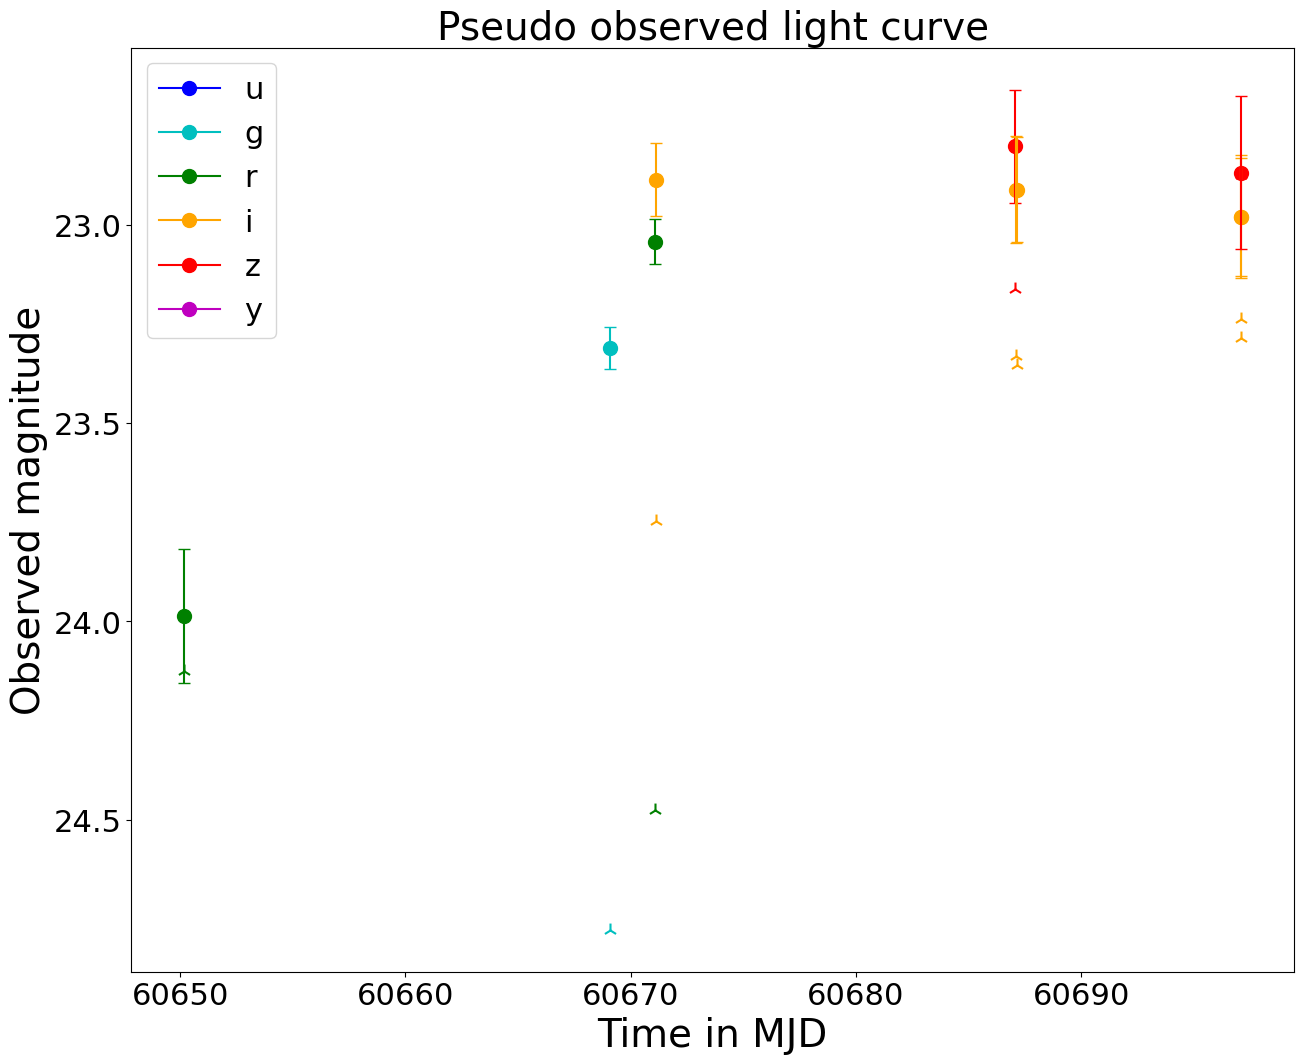

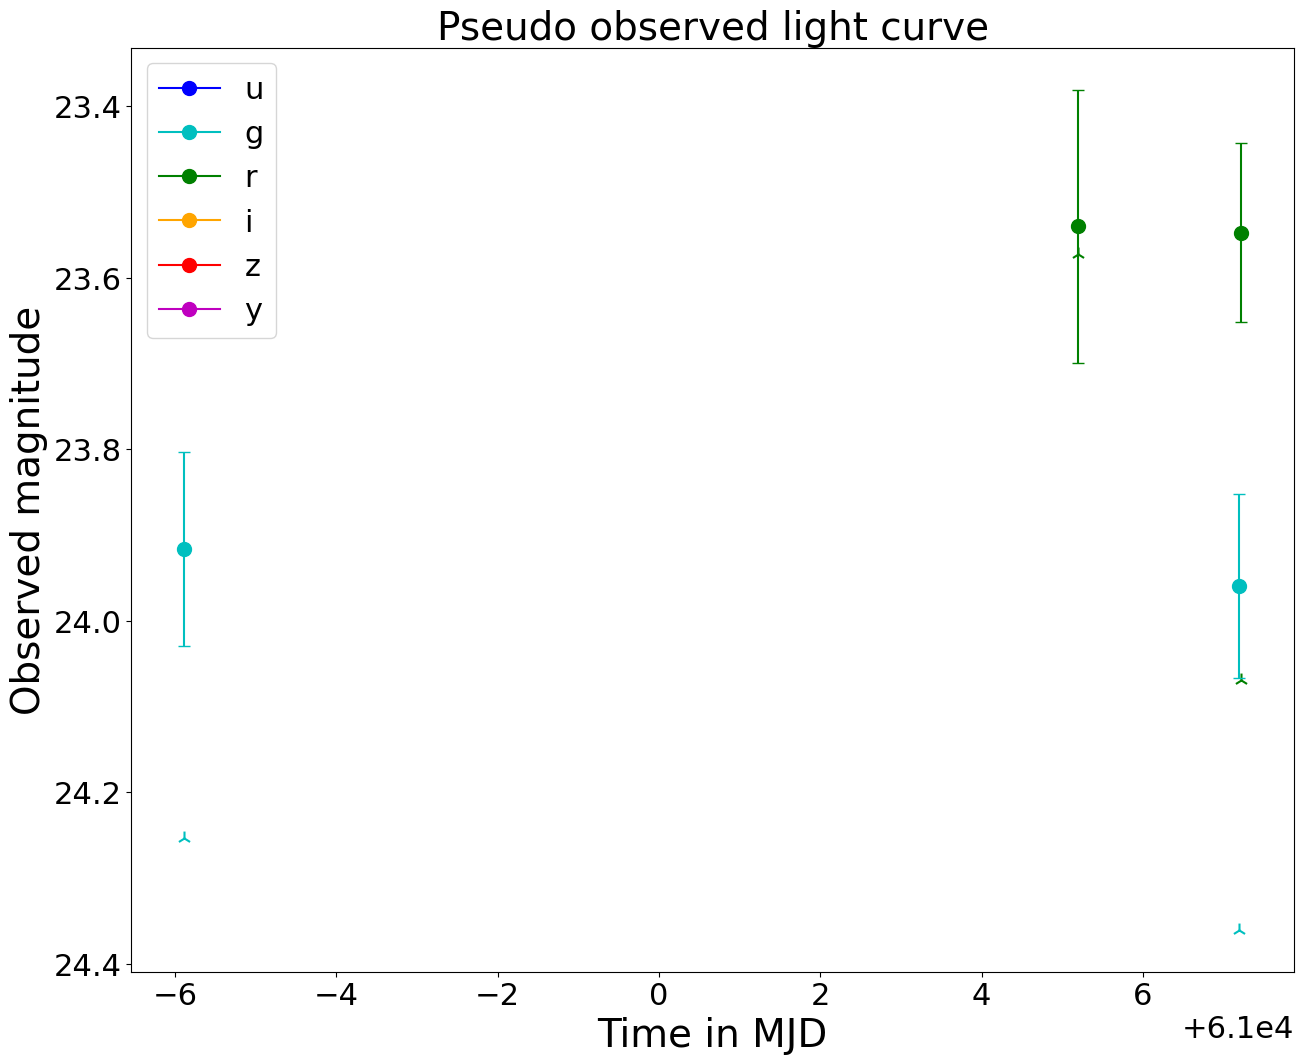

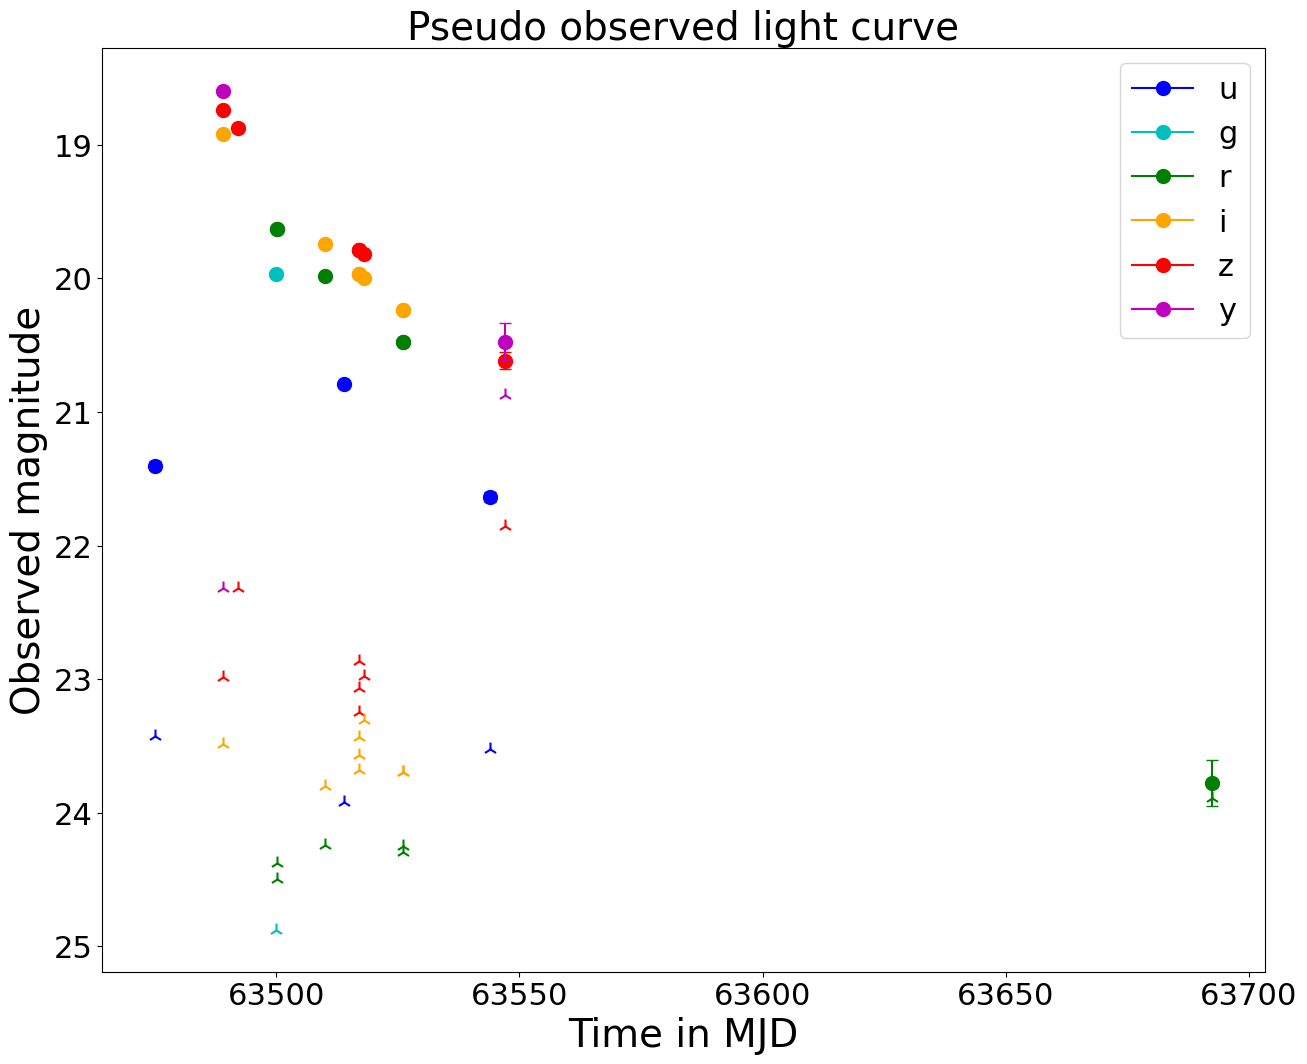

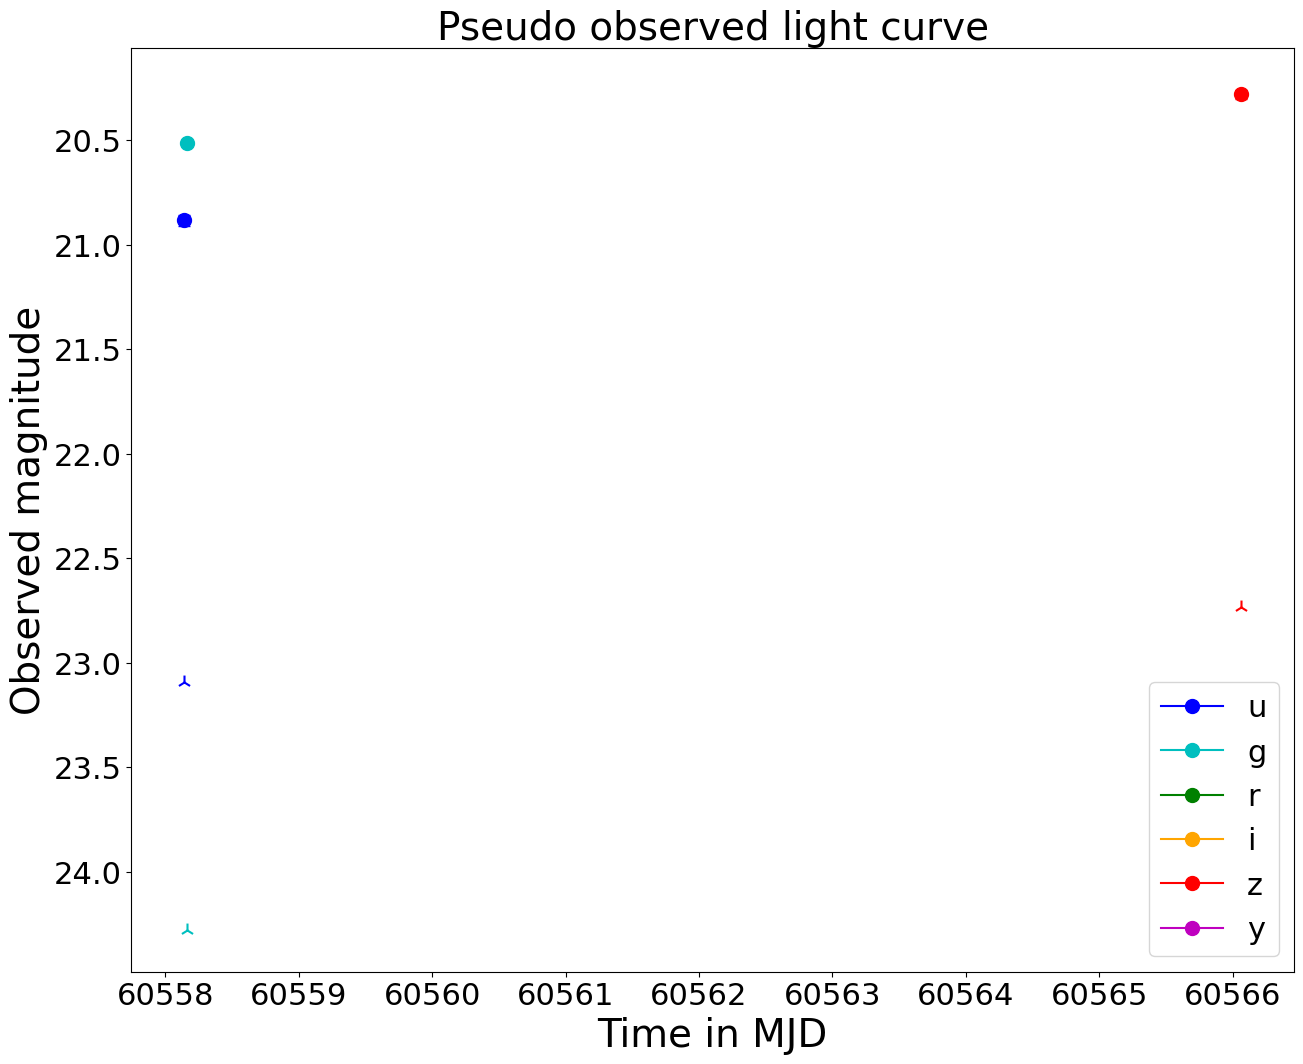

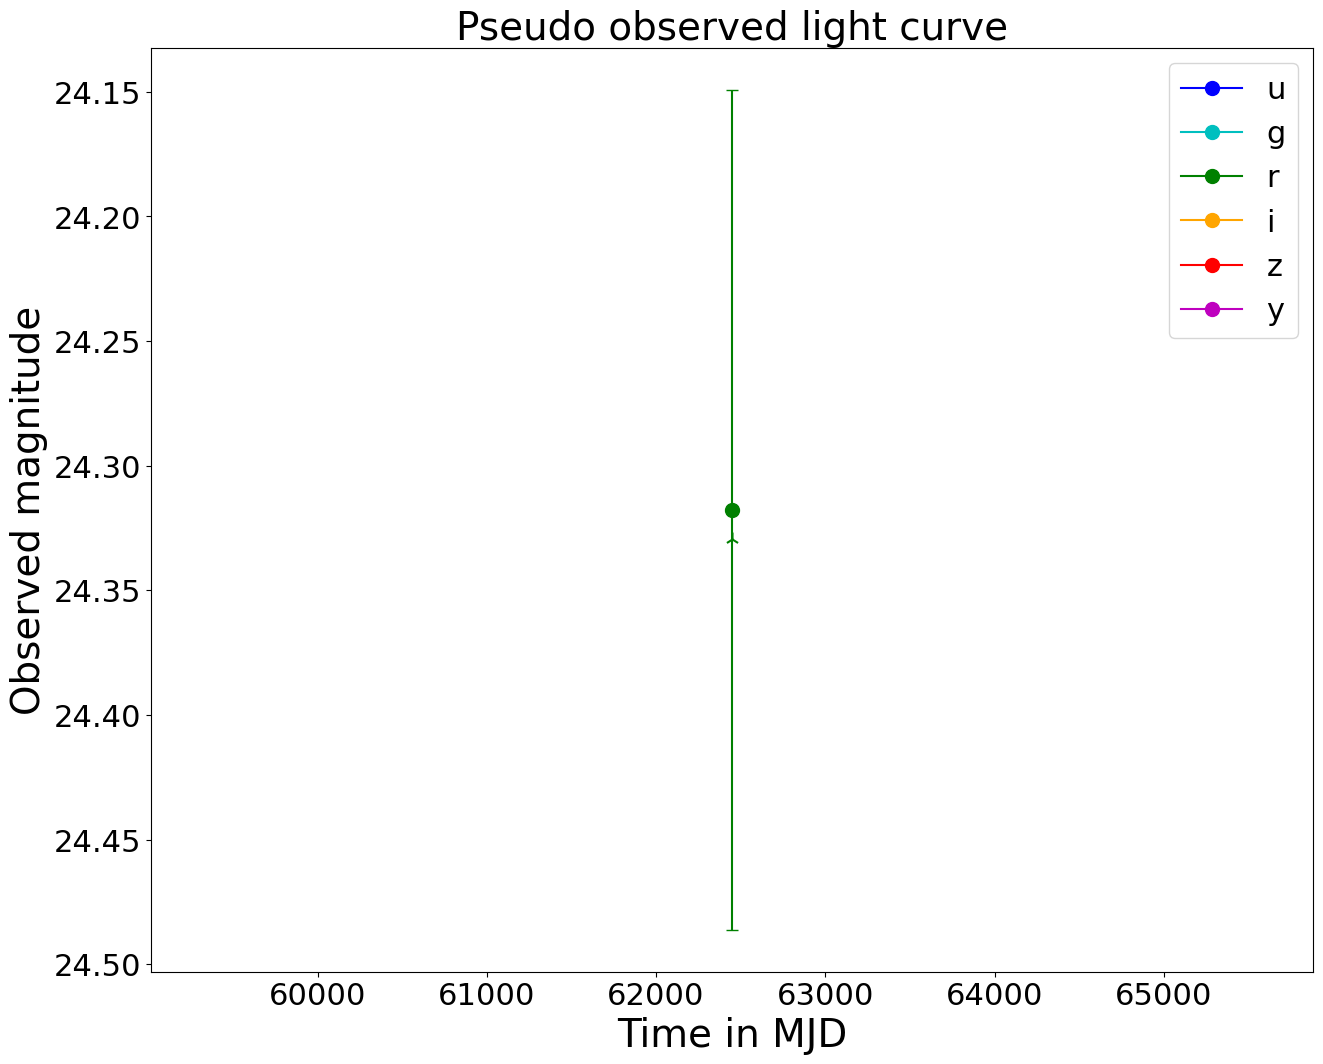

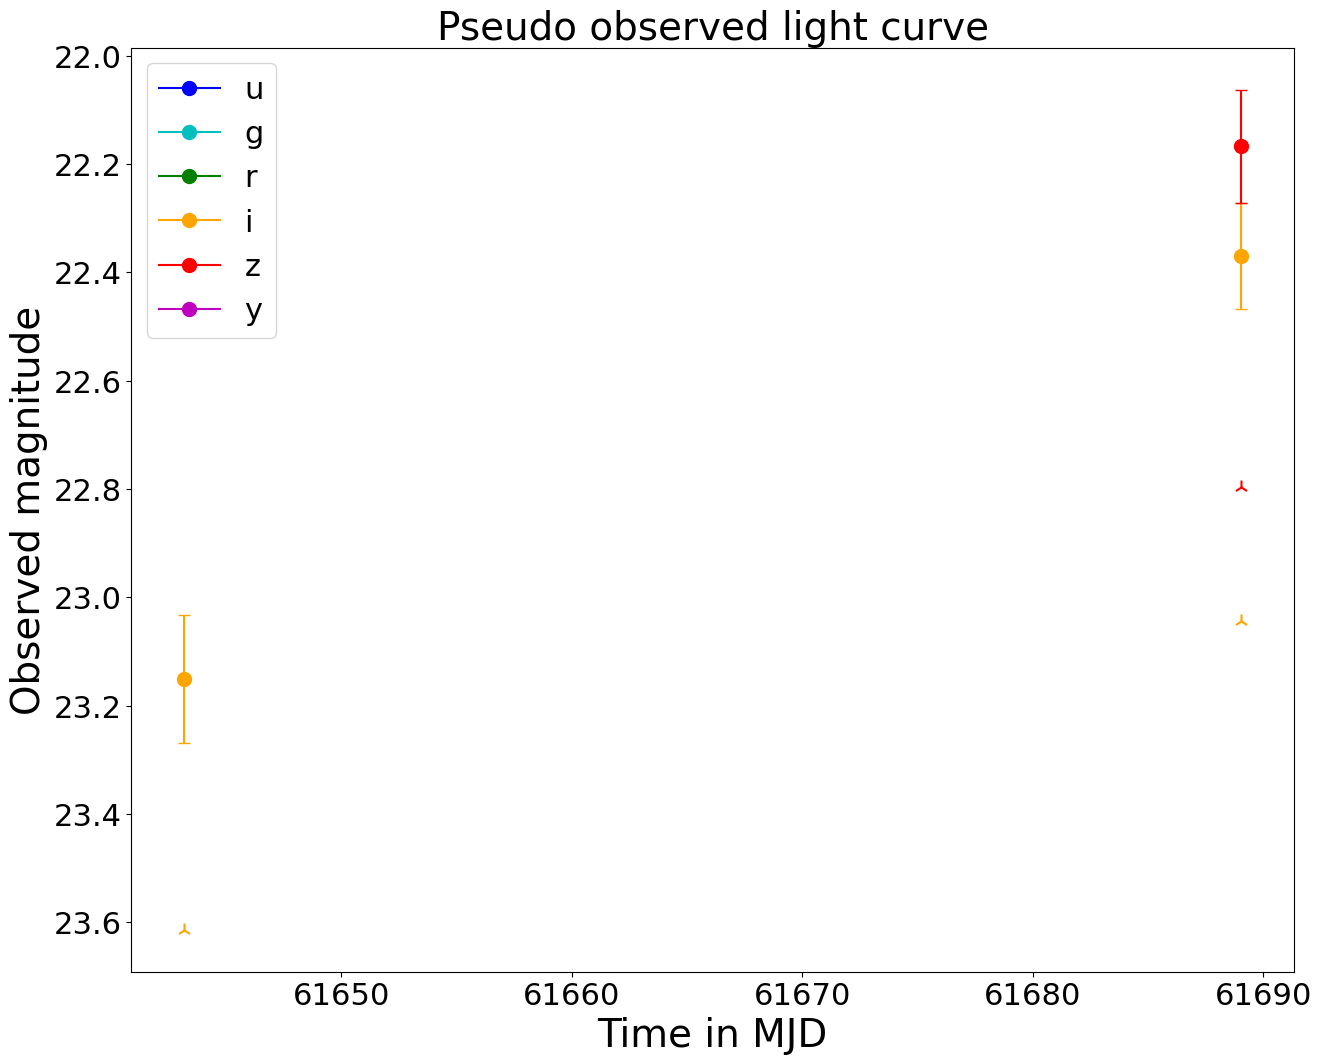

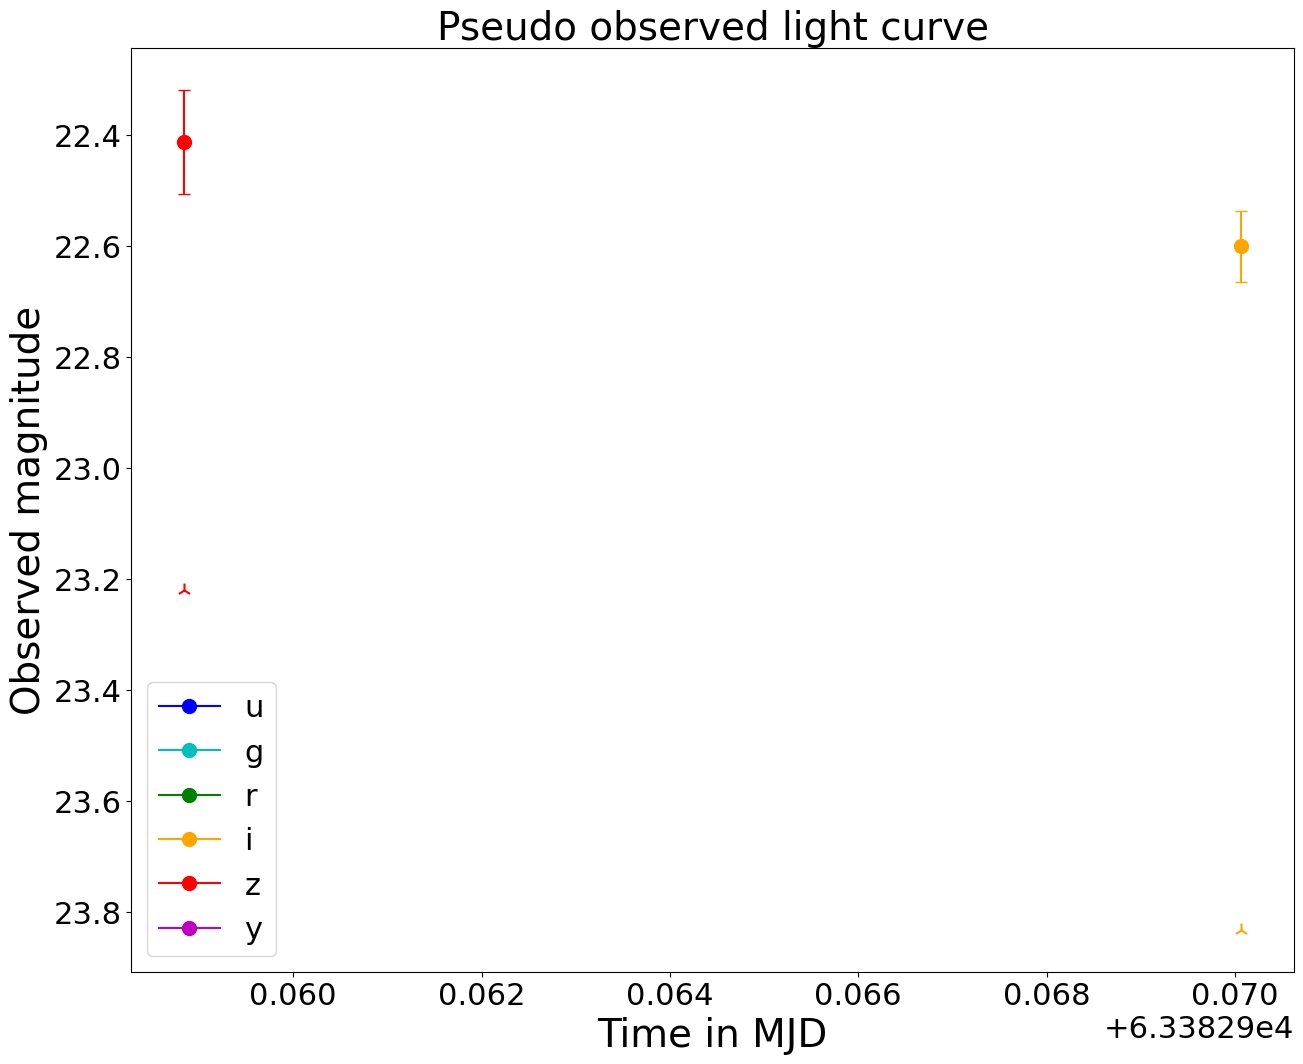

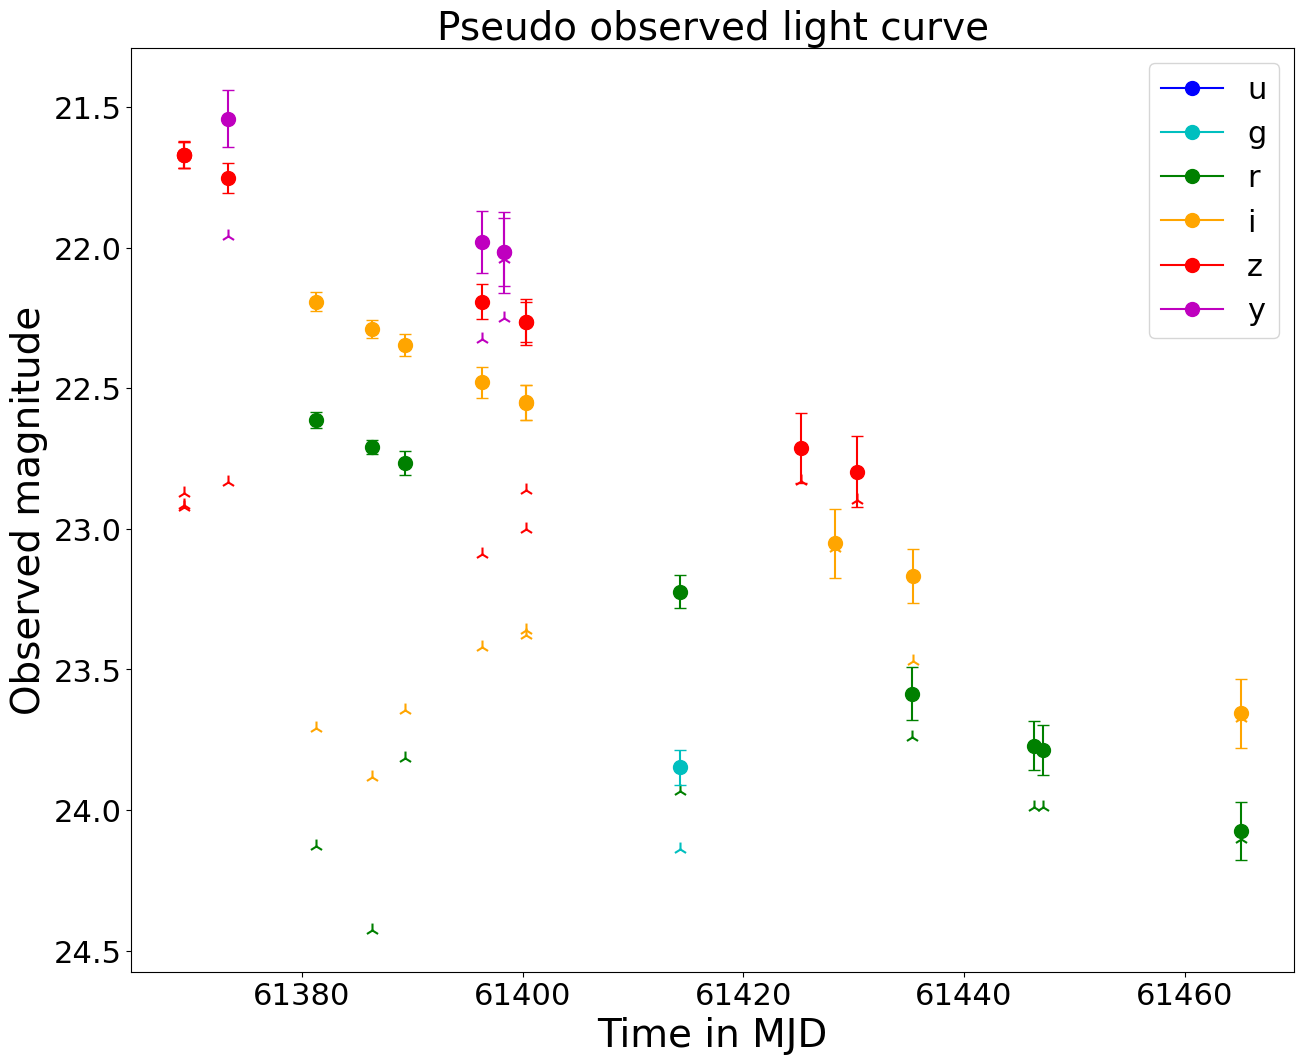

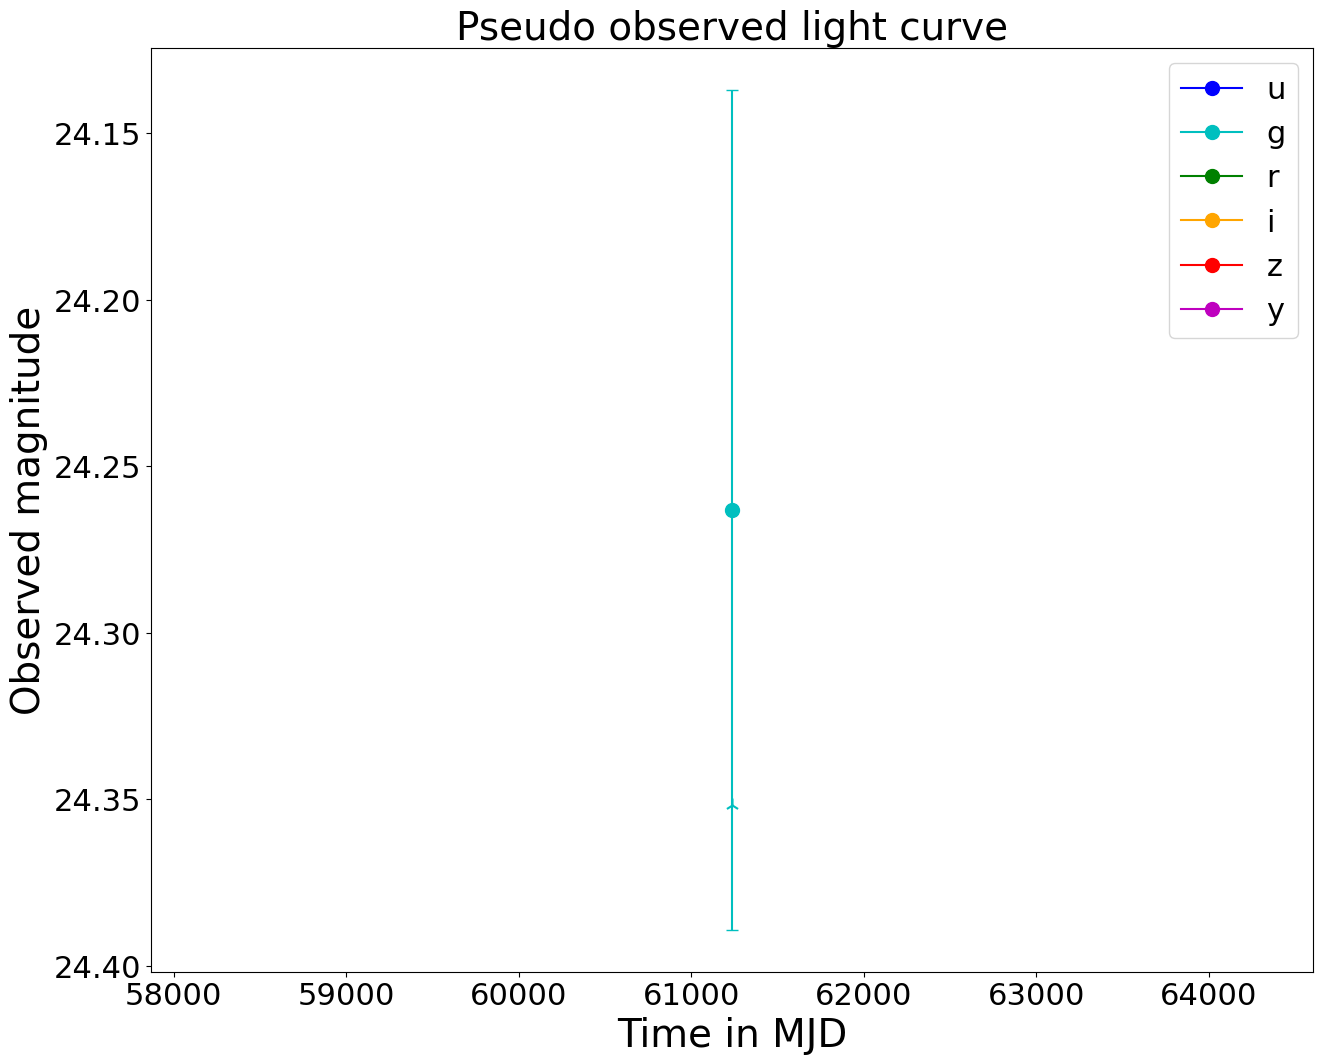

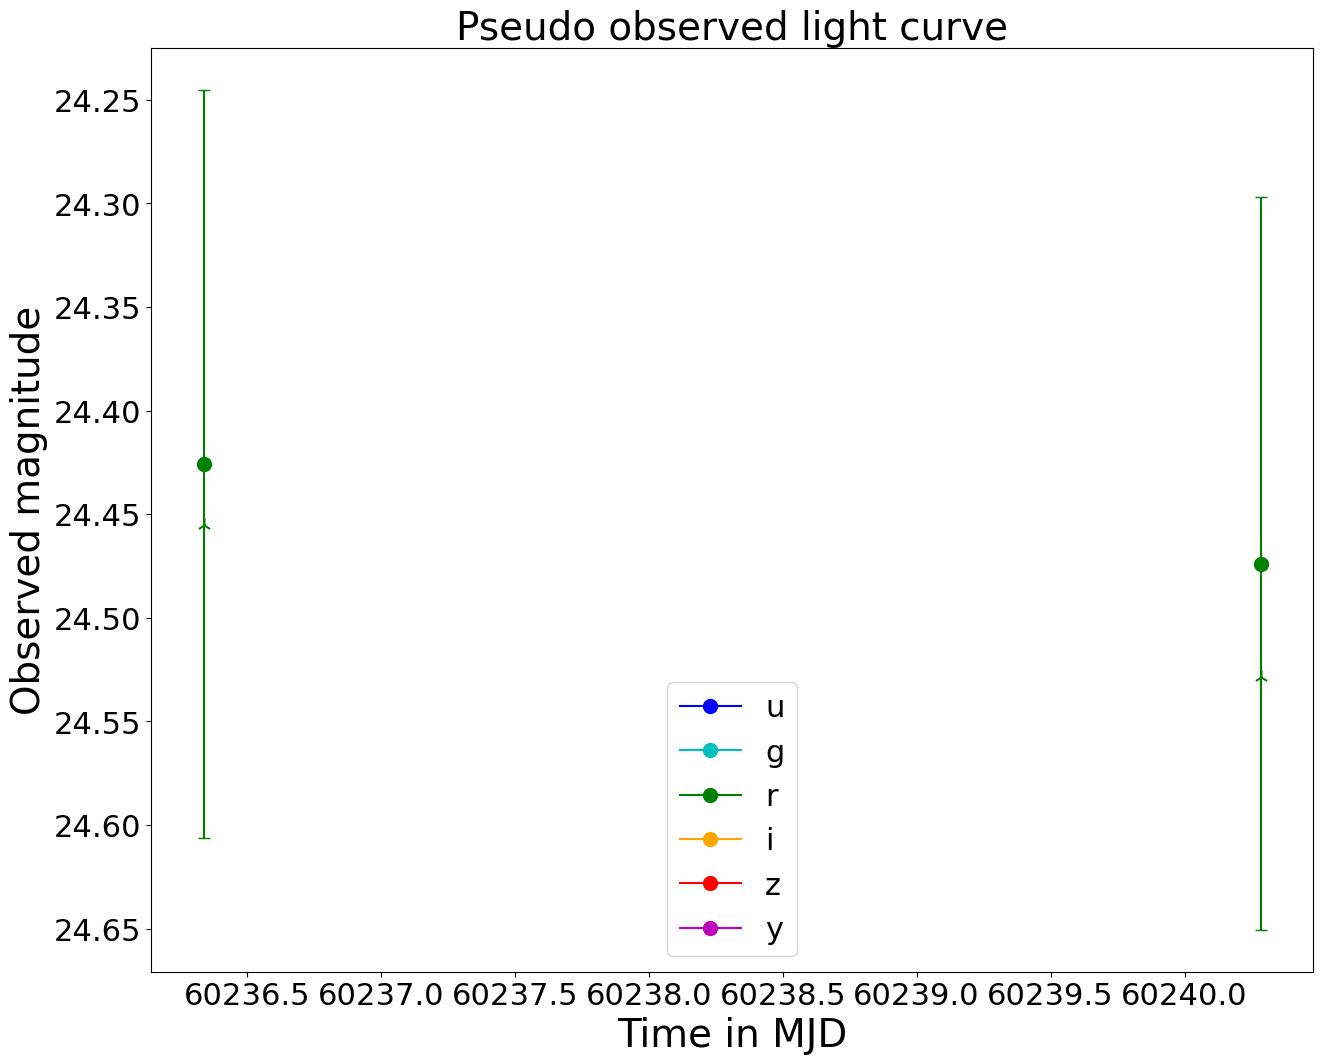

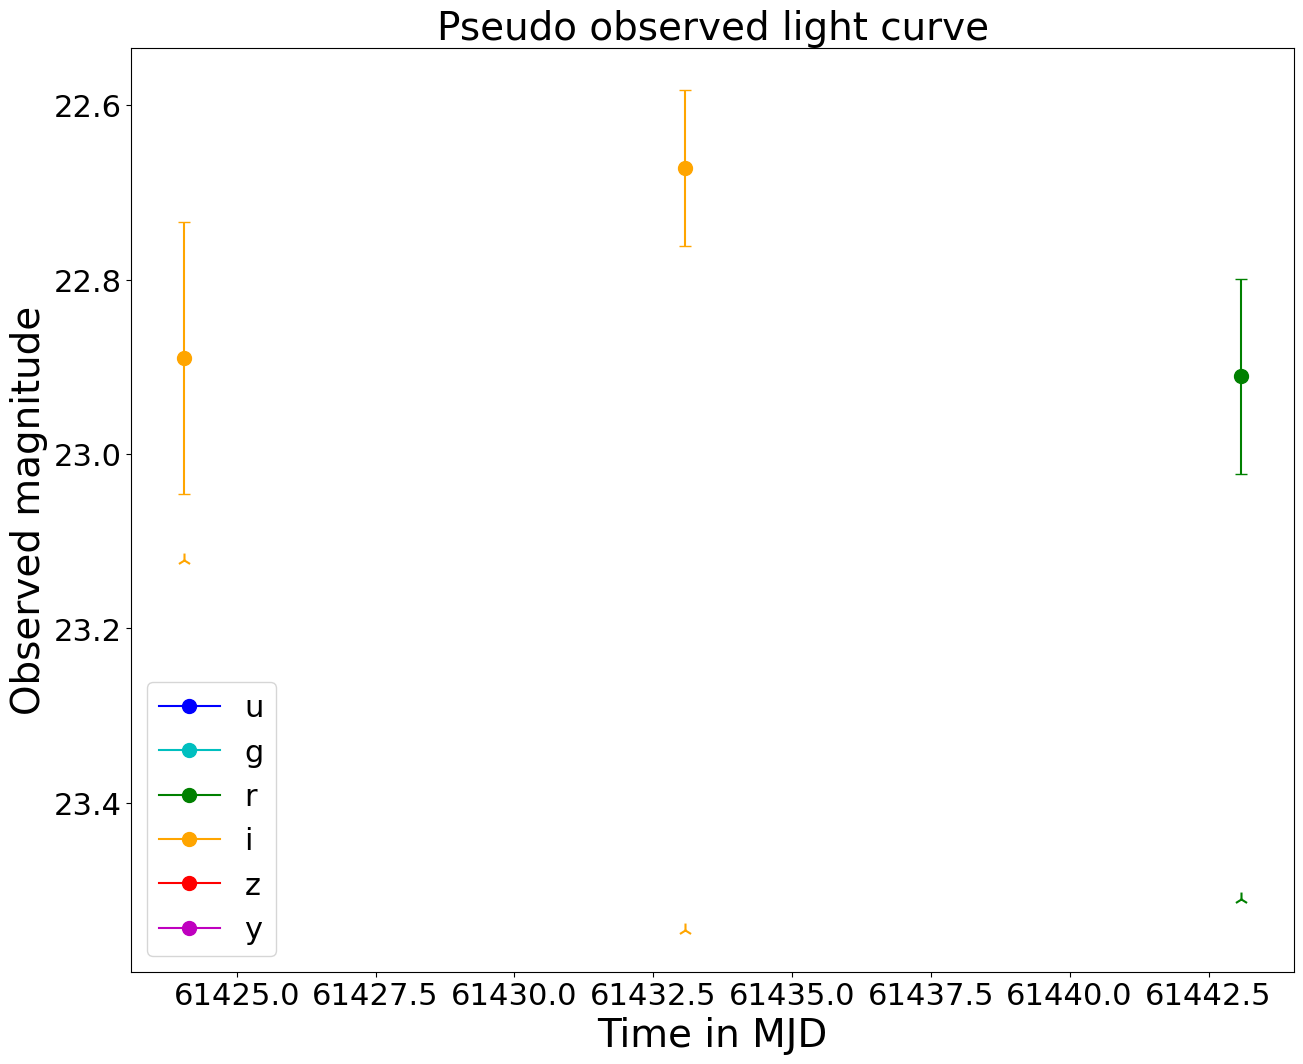

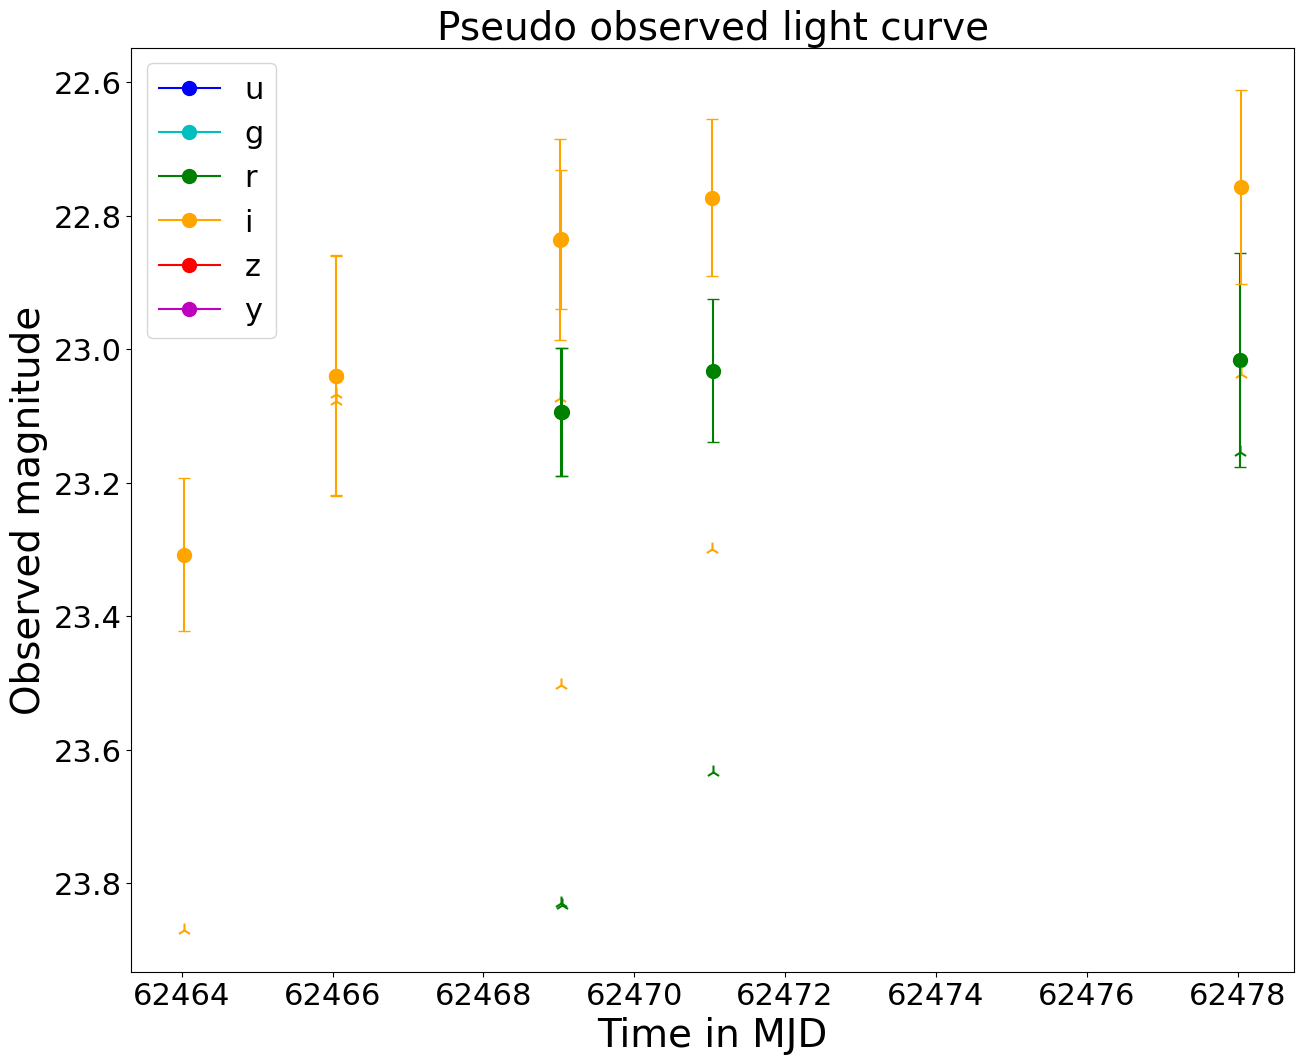

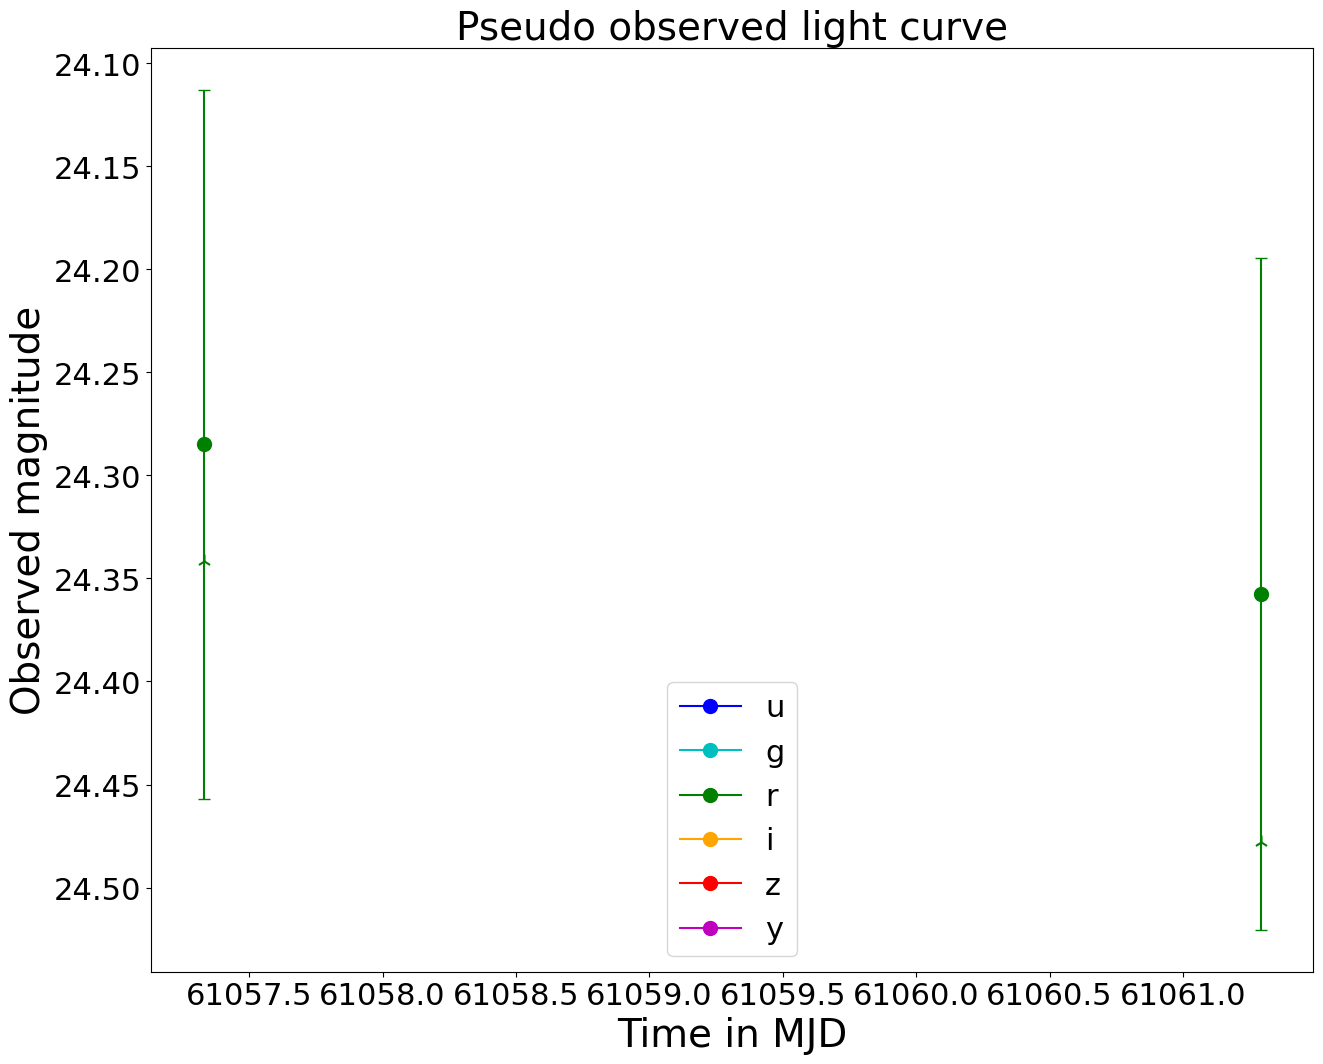

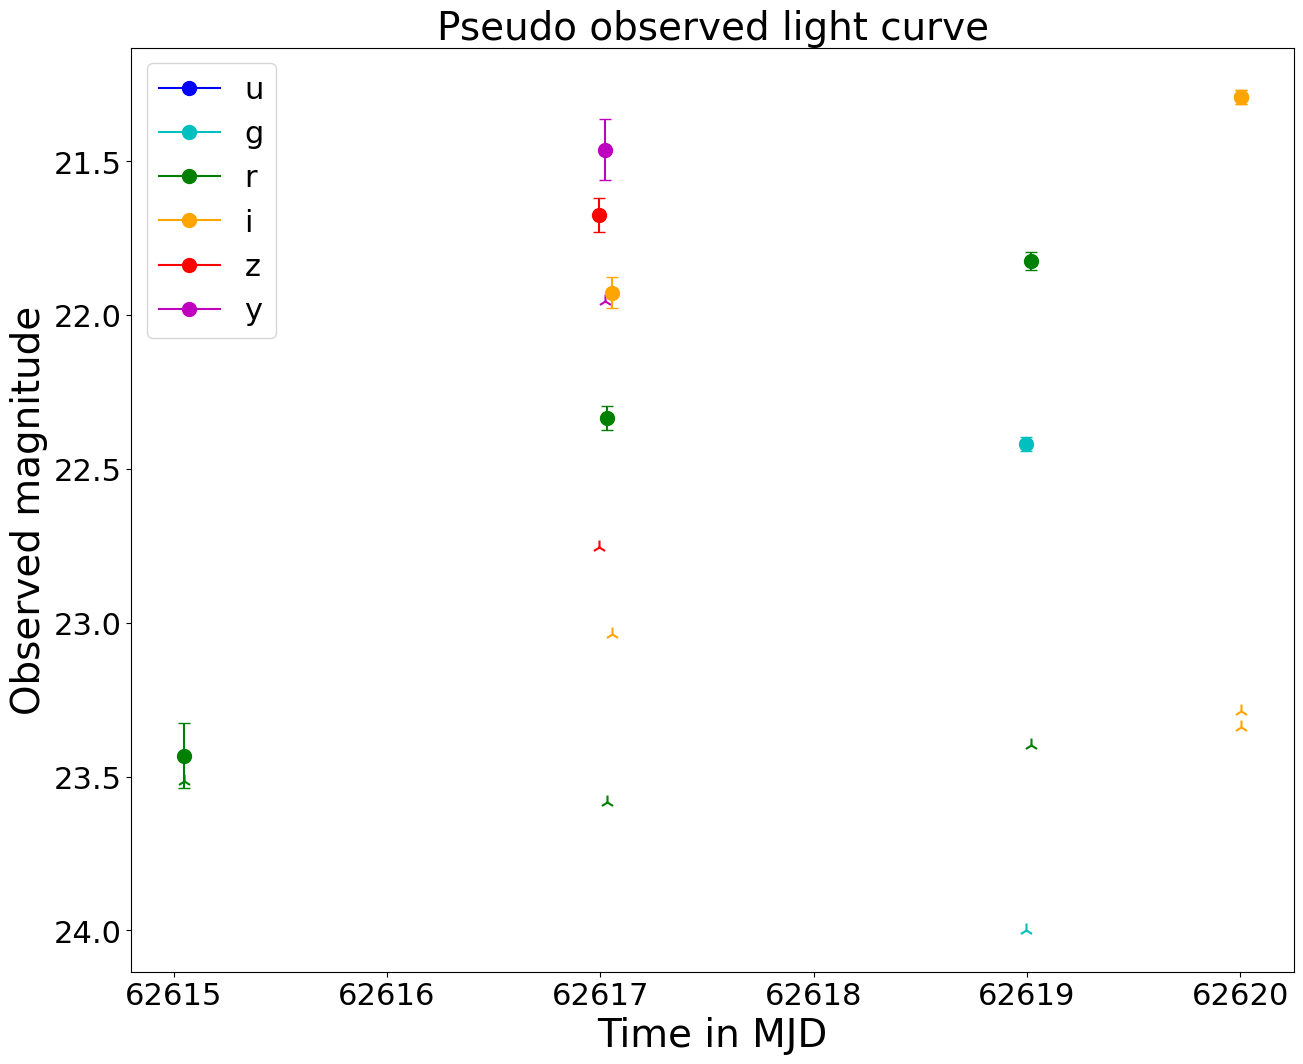

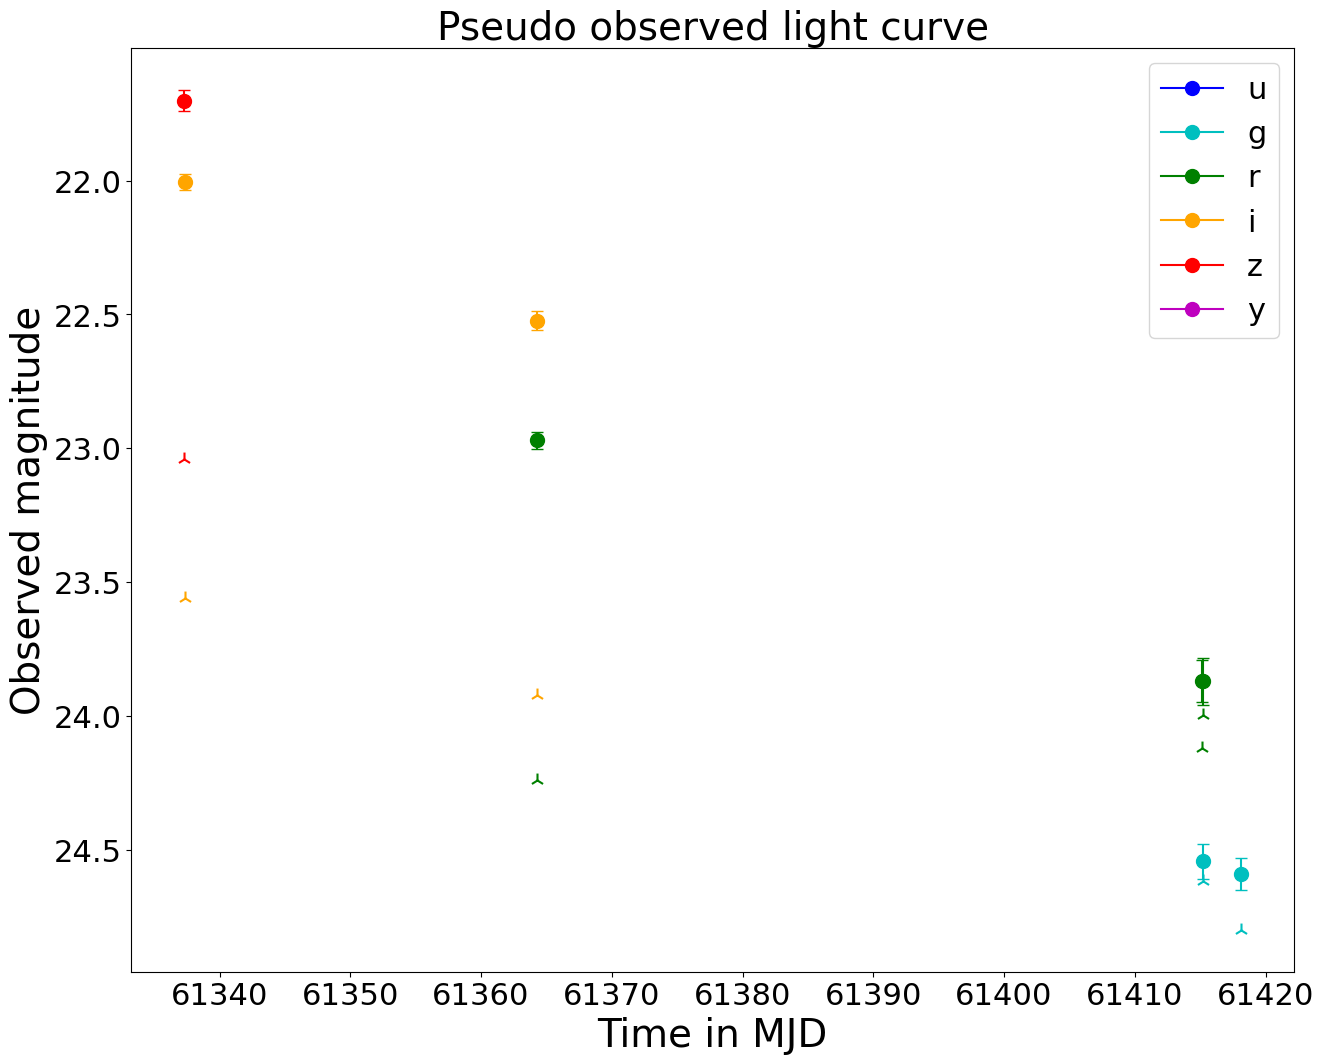

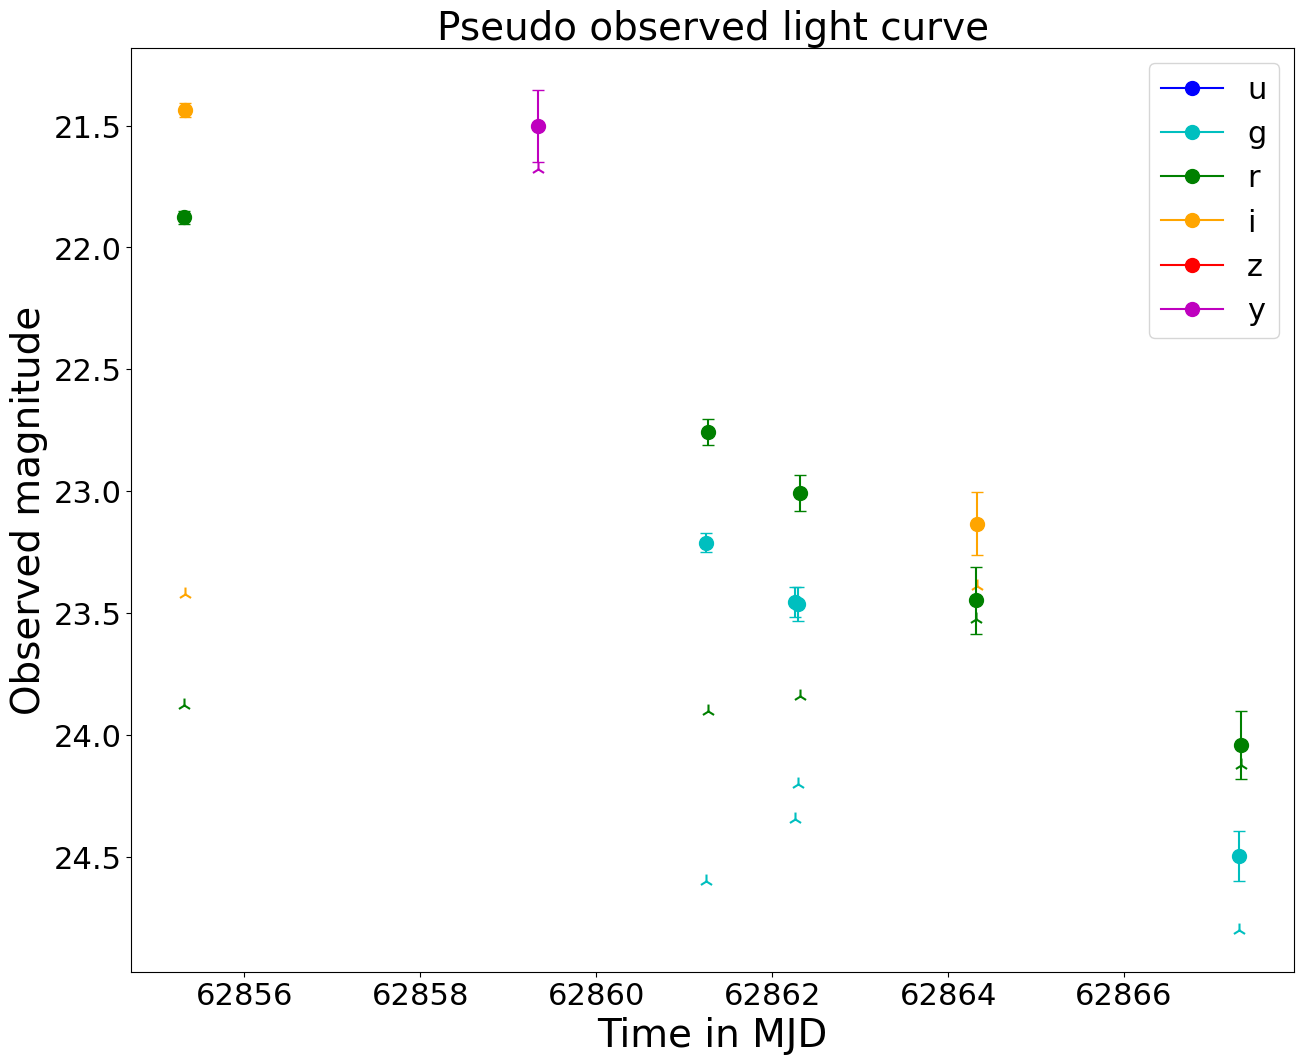

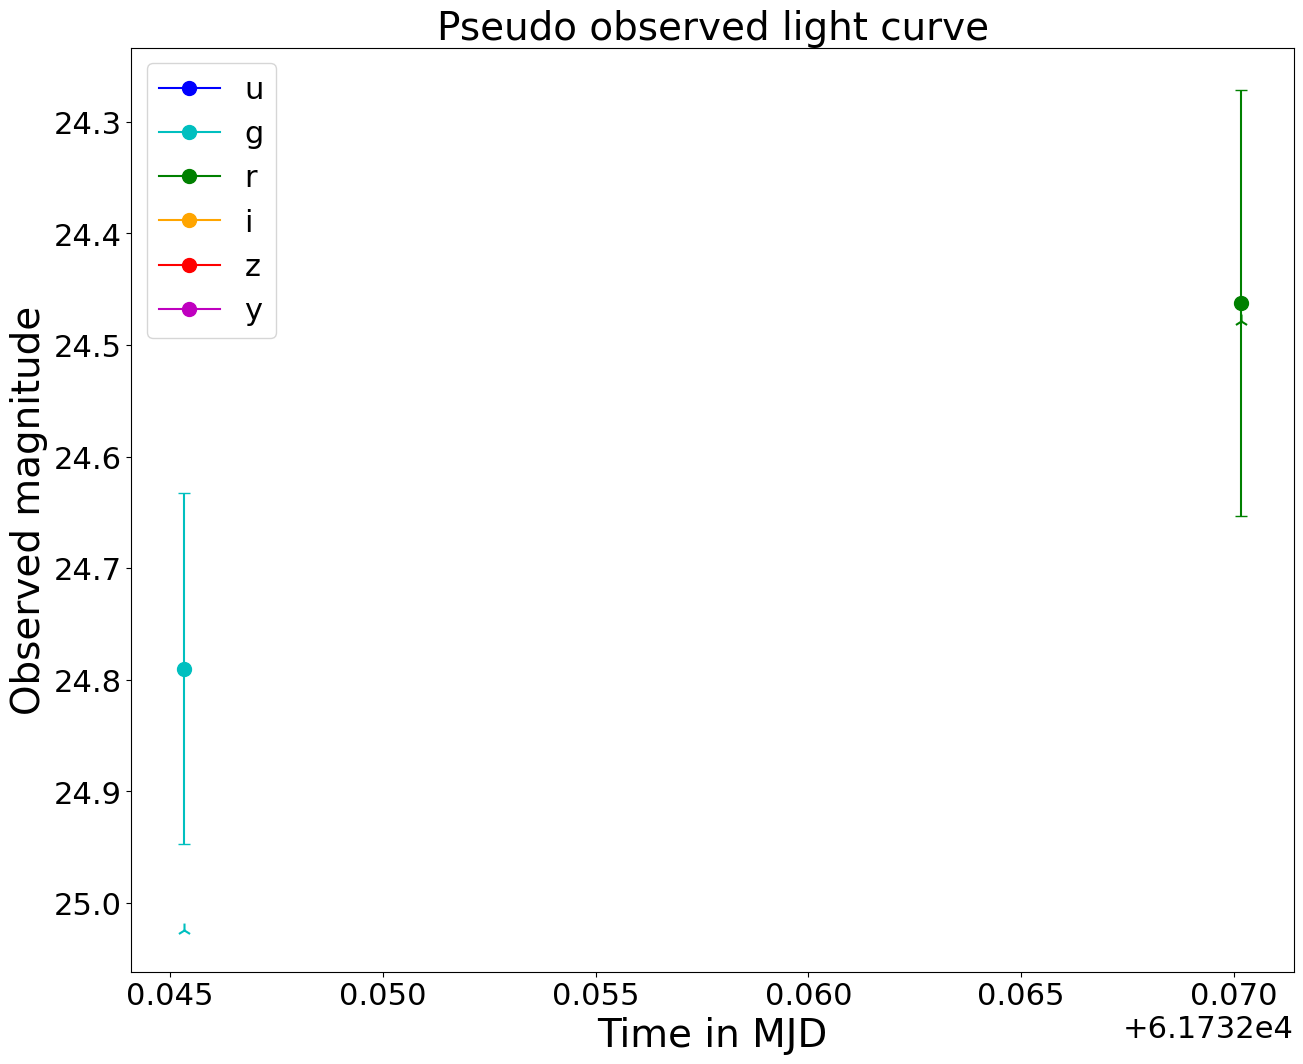

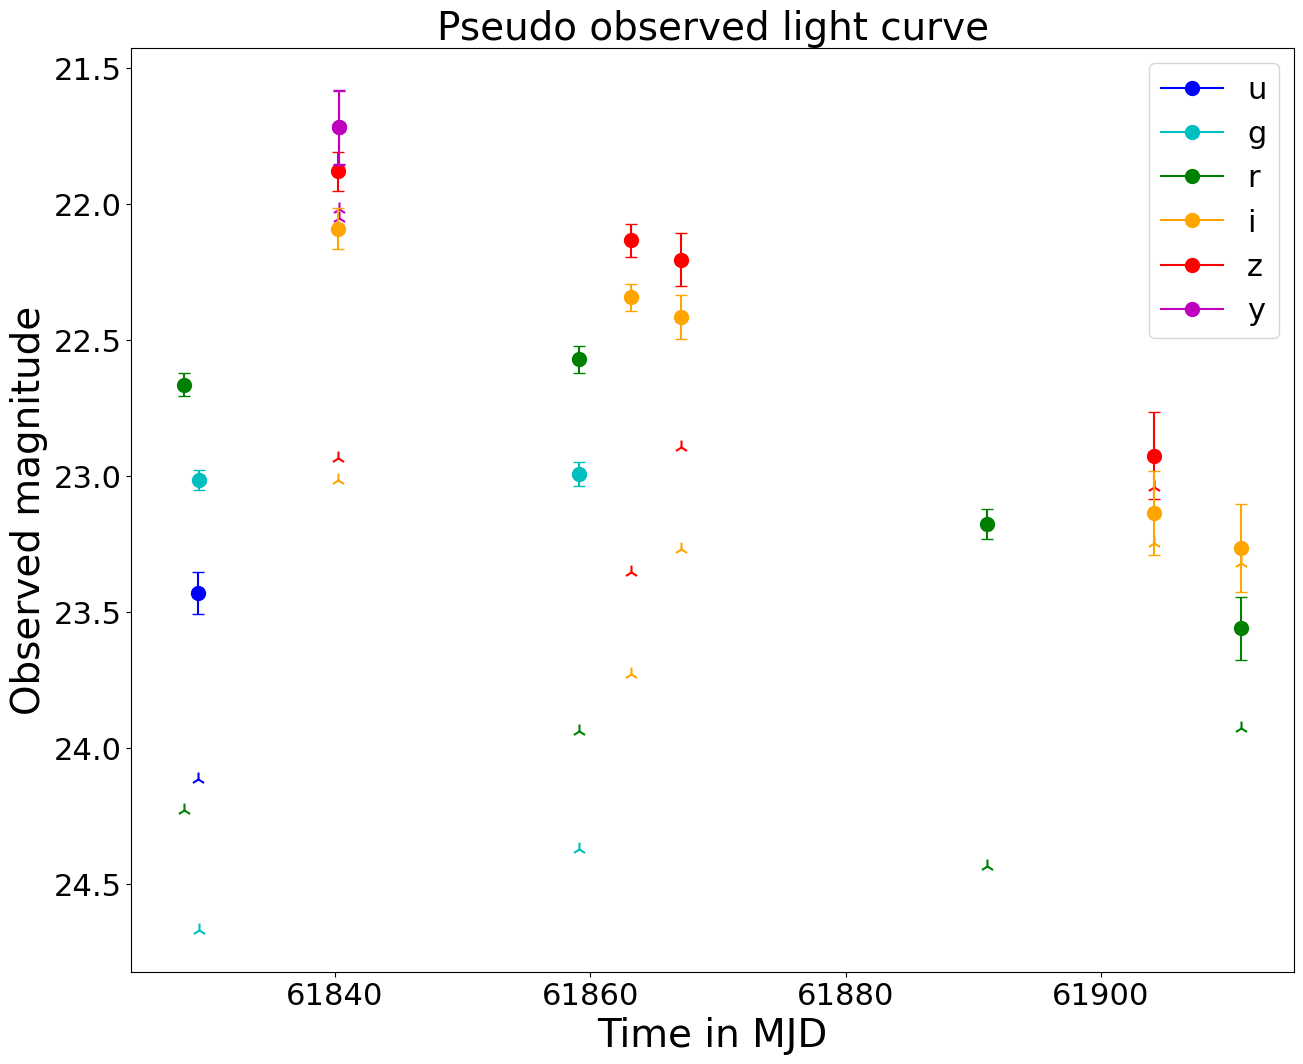

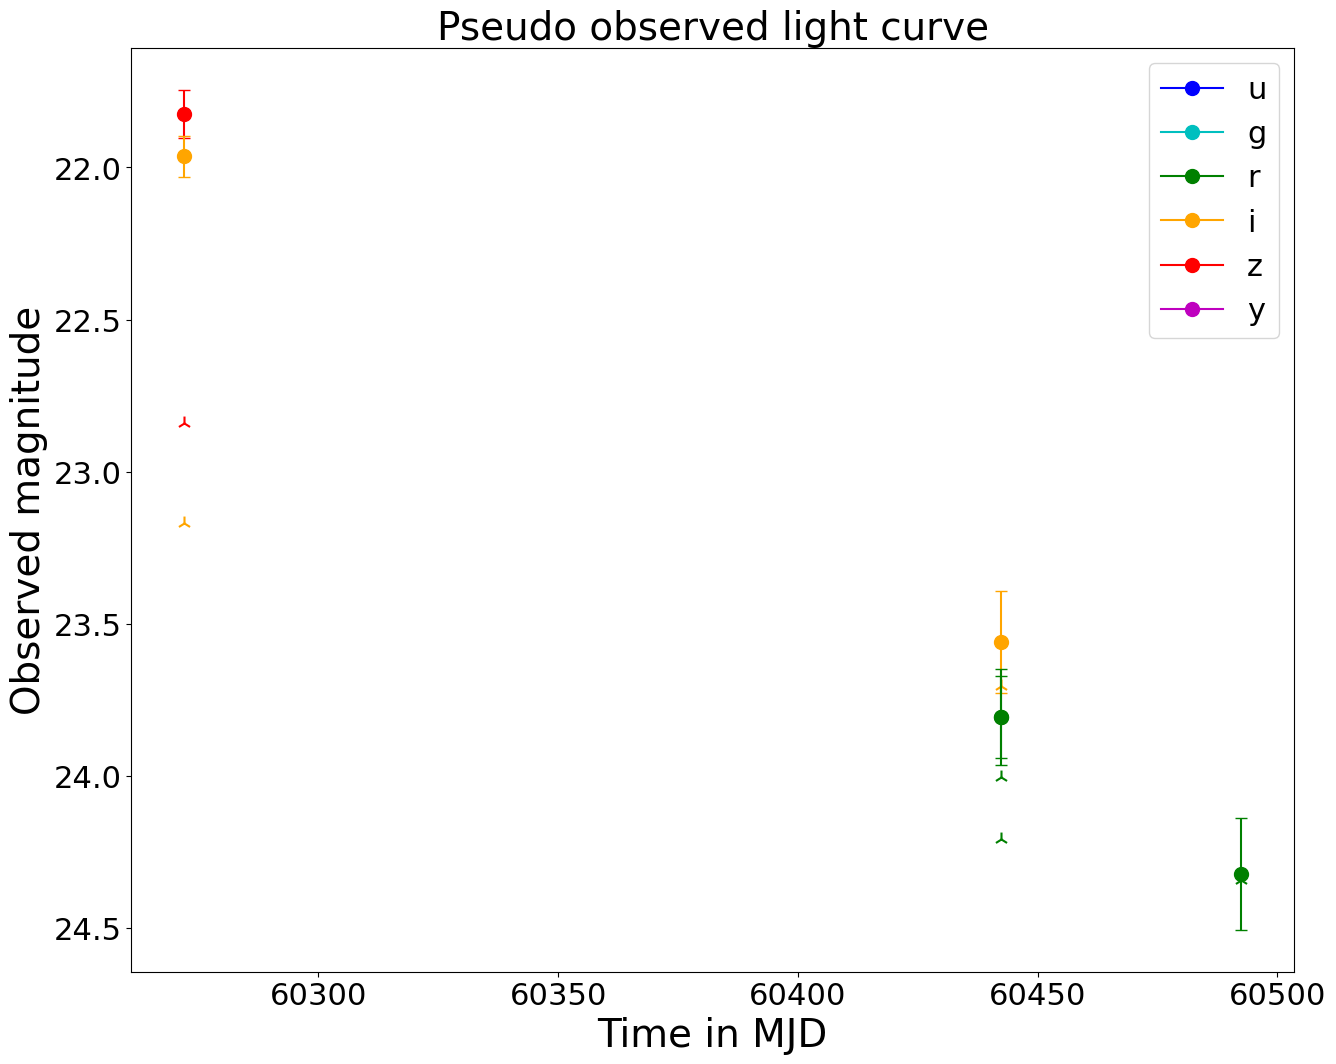

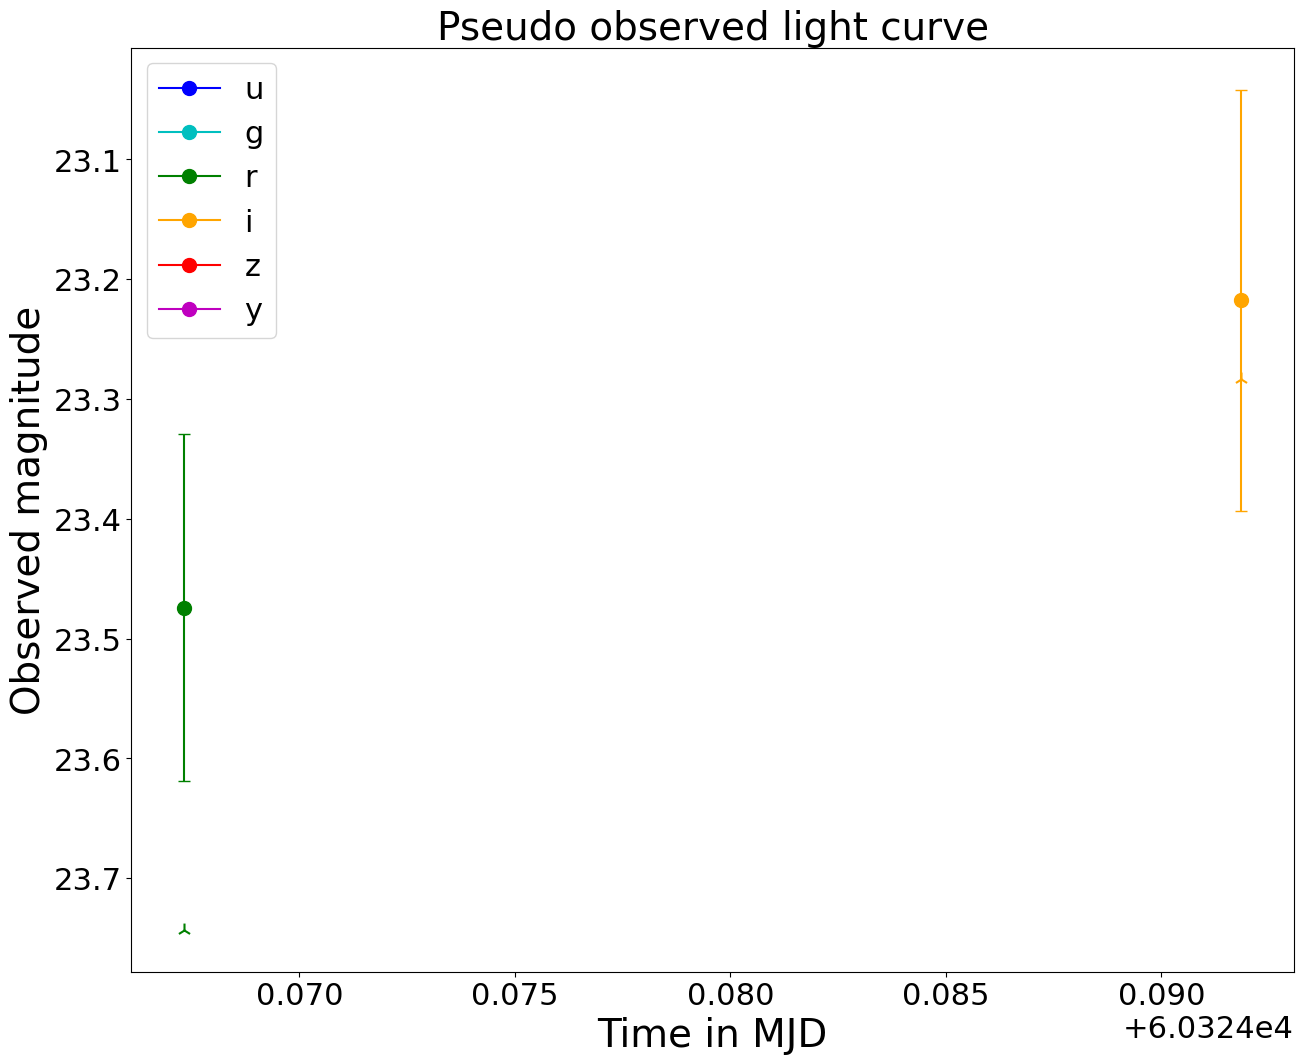

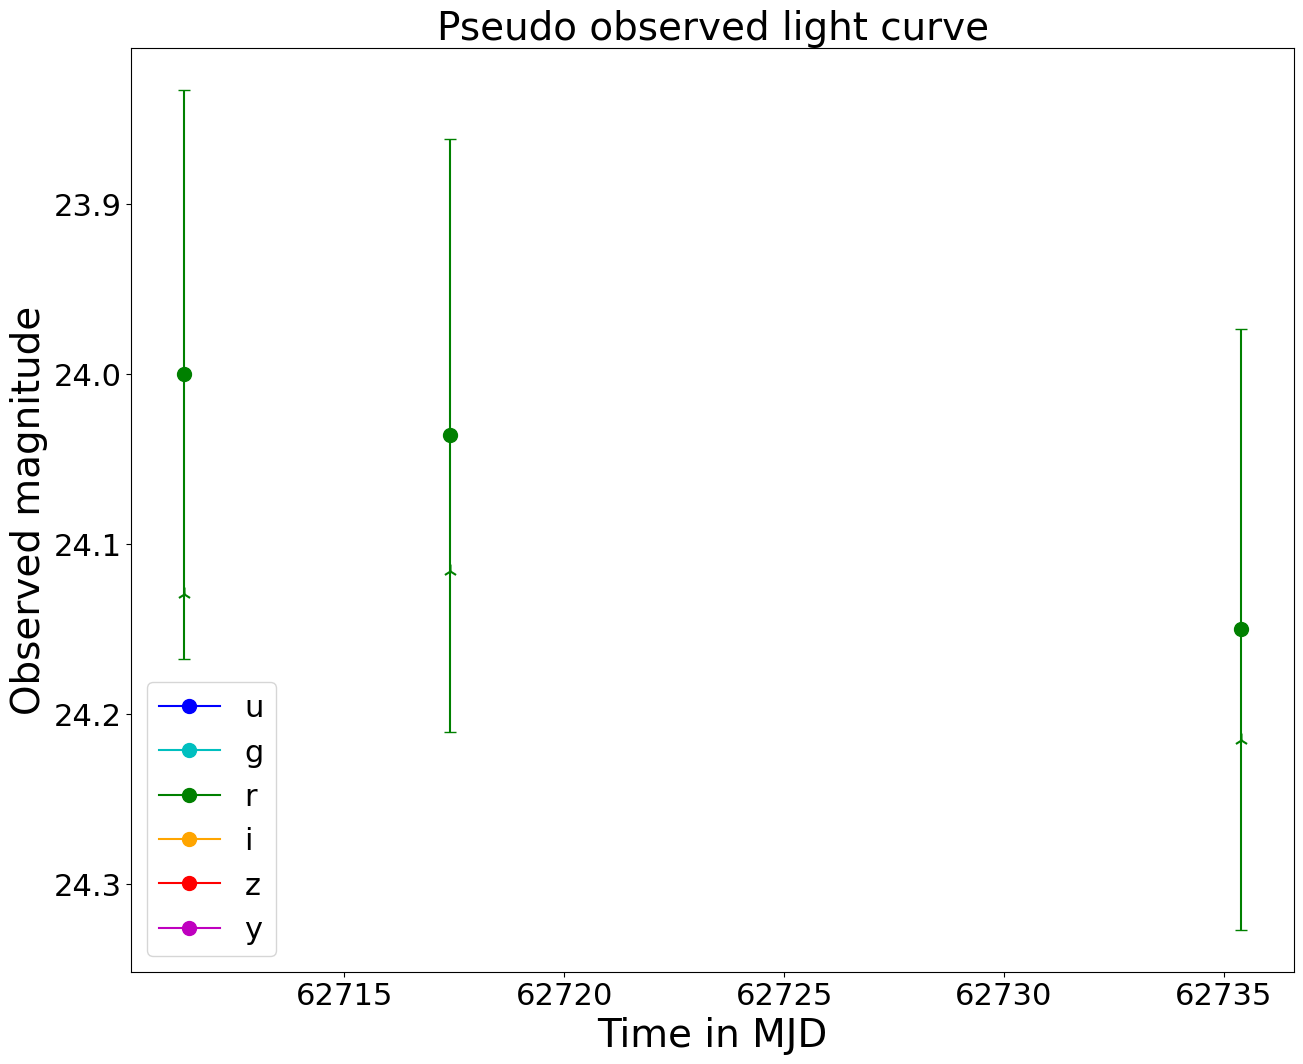

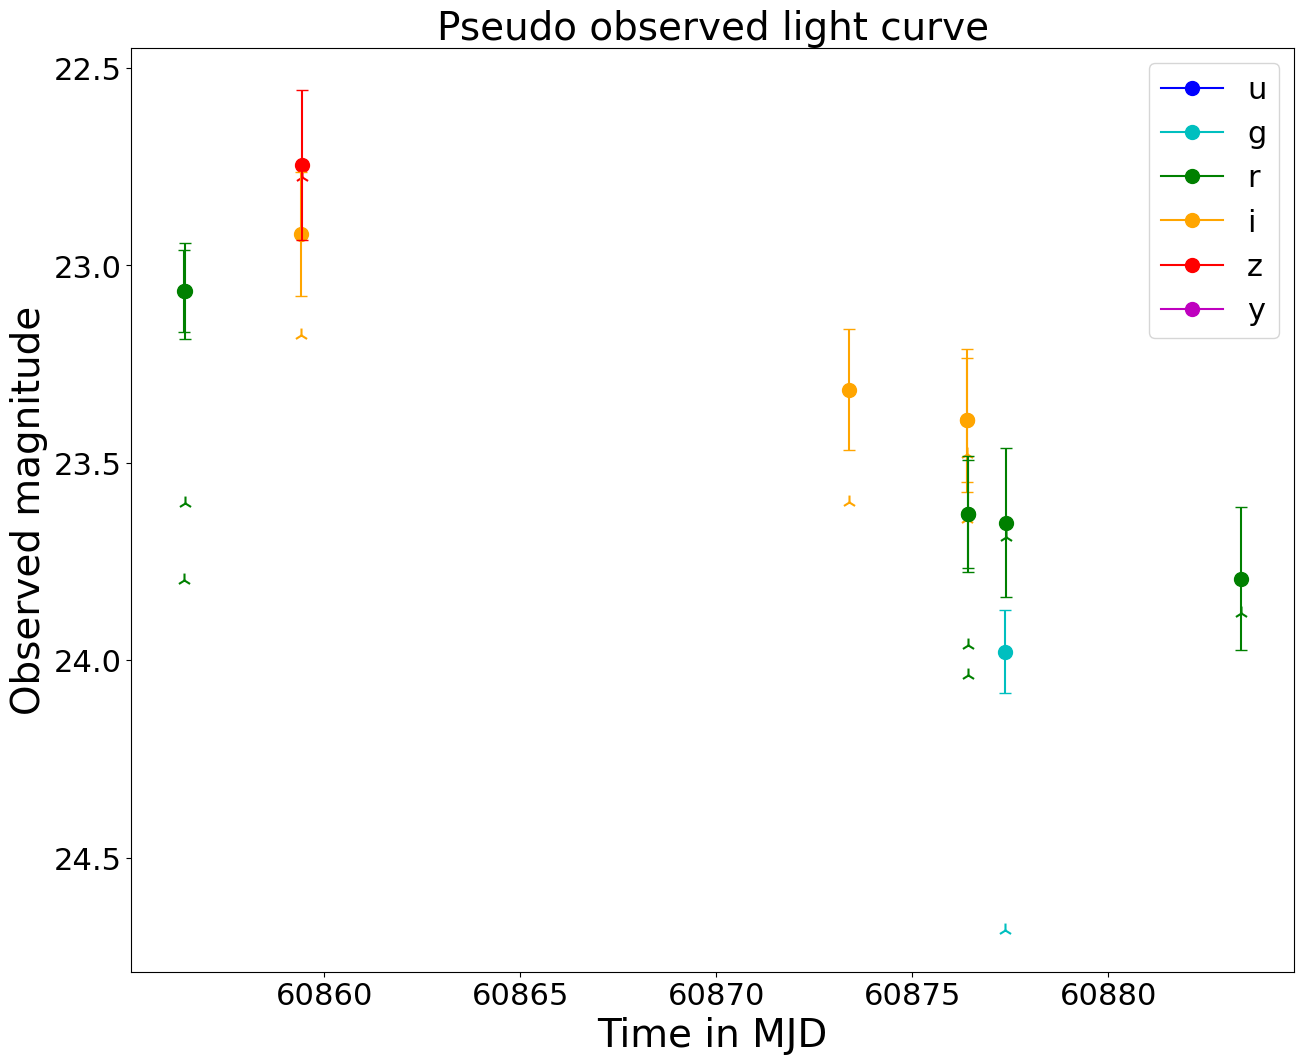

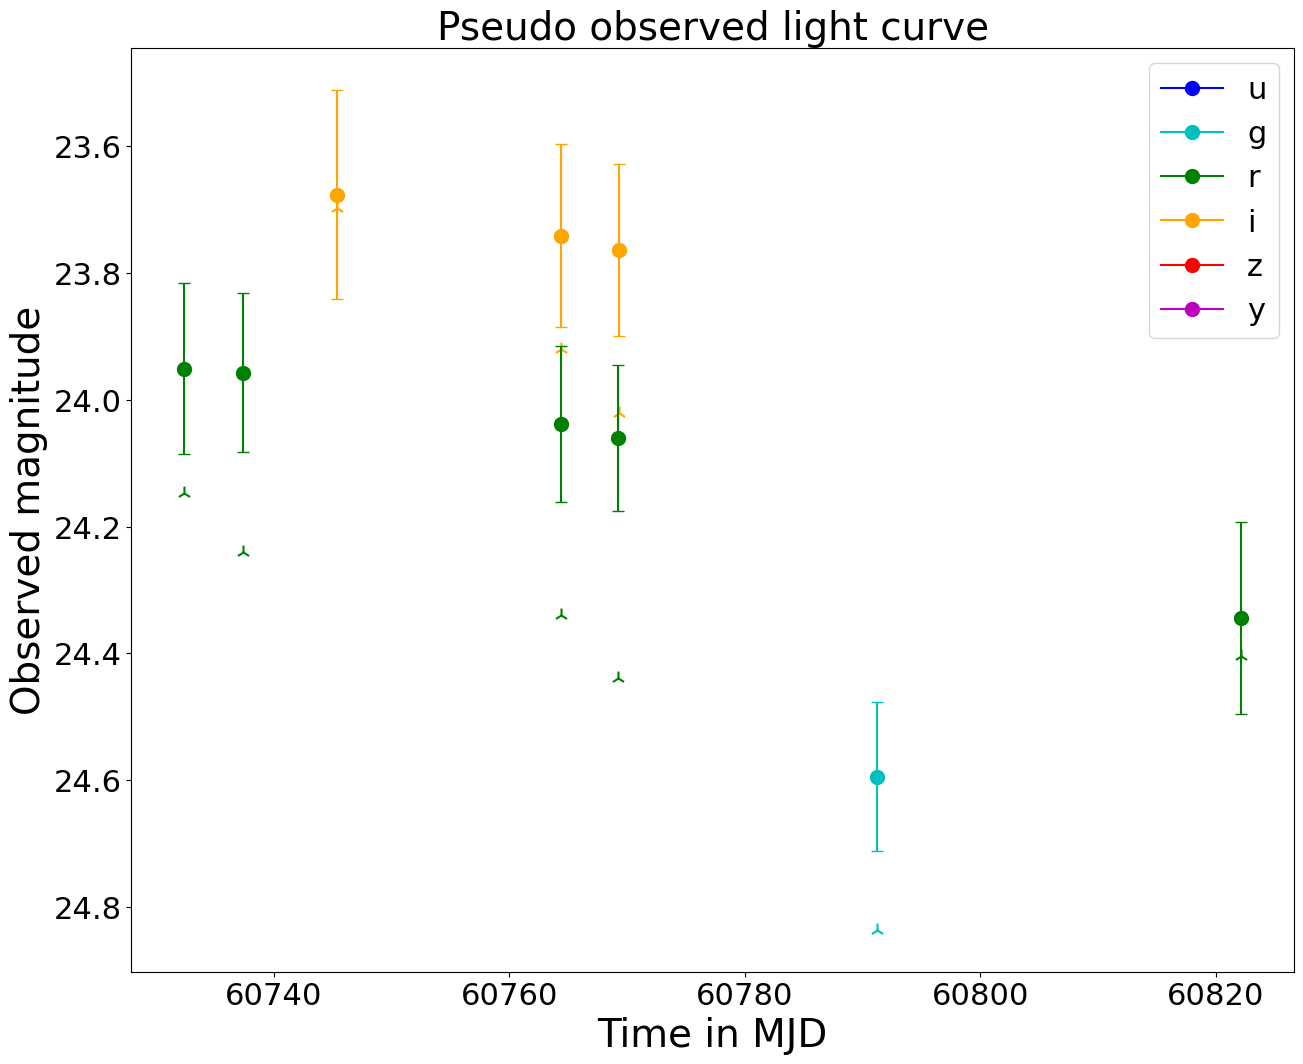

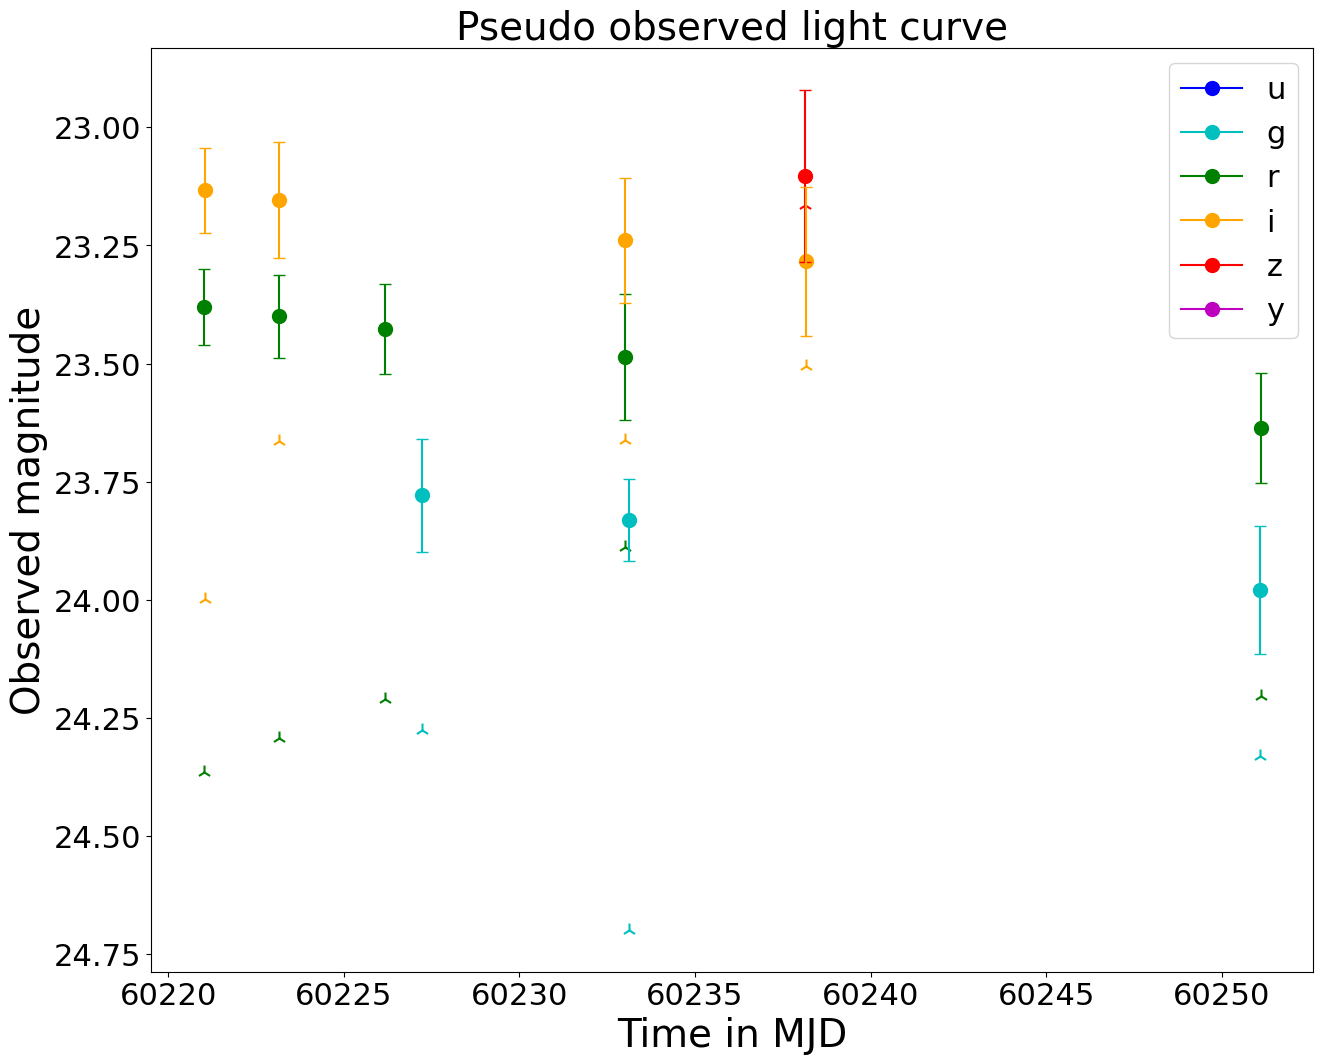

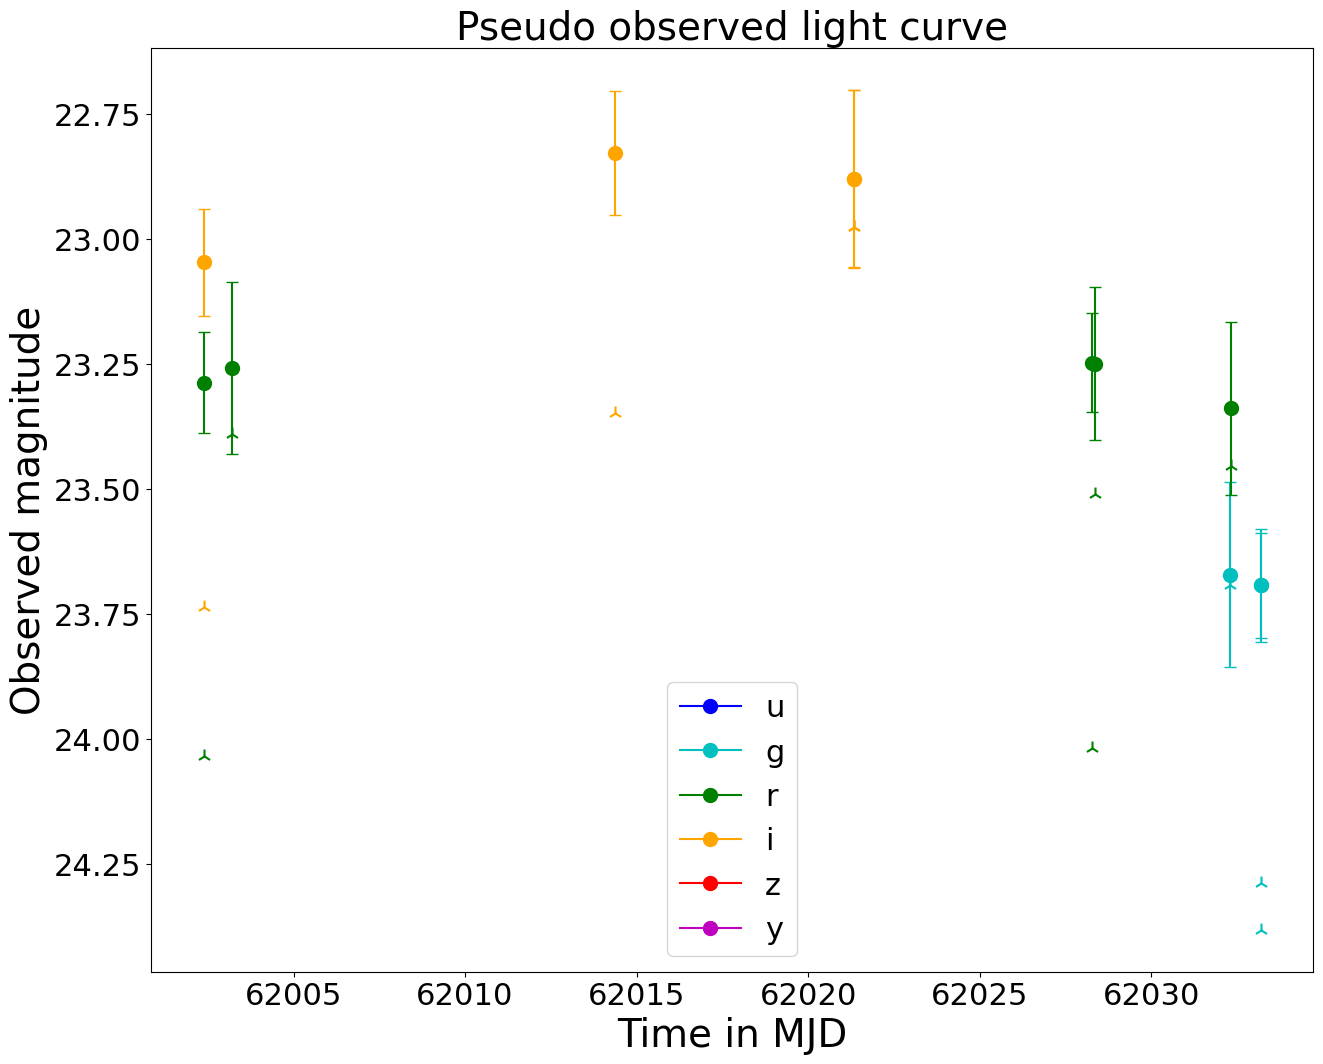

In [124]:
for i in range(len(lc_with_pts)):

    plot_pseudo_obs(lc_with_pts[i])

## Calculating features from pseudo-observations

Determine and calculate some features from the pseudo-observed light curve in order to describe their shape and to study their similarities:
- Minimal magnitude, 
- Time of the peak, 
- Duration between the first and the peak, 
- Increasing rate and decreasing rates in the 1/3 and 3/3 parts of the decreasing phase,
- g-r color. 

### Minimal magnitude

In [46]:
# minimal magnitude
mag_min = minimal_magnitude(pseudo_obs)

Text(0, 0.5, 'number of GRBs')

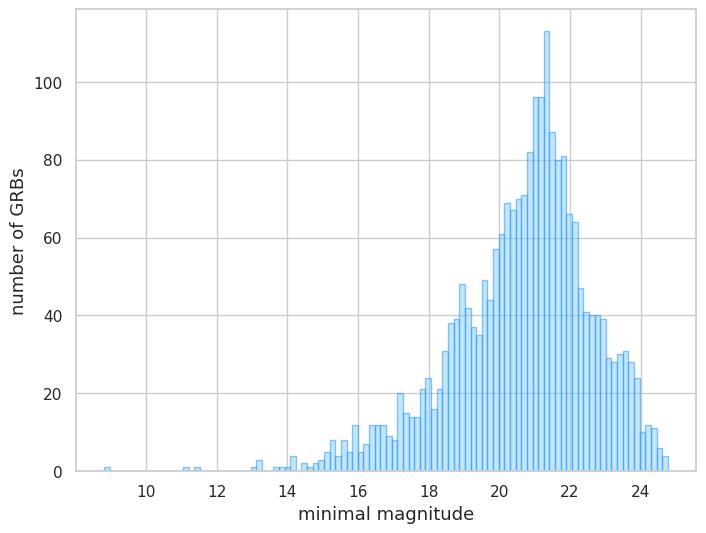

In [47]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 6))

plt.hist(mag_min, bins=100, color='skyblue', edgecolor='dodgerblue', alpha=0.5)

plt.xlabel('minimal magnitude', fontsize=13)
plt.ylabel('number of GRBs', fontsize=13)

### Time of the minimal magnitude

In [48]:
# time of the minimal magnitude
time_max = peak_time(pseudo_obs)

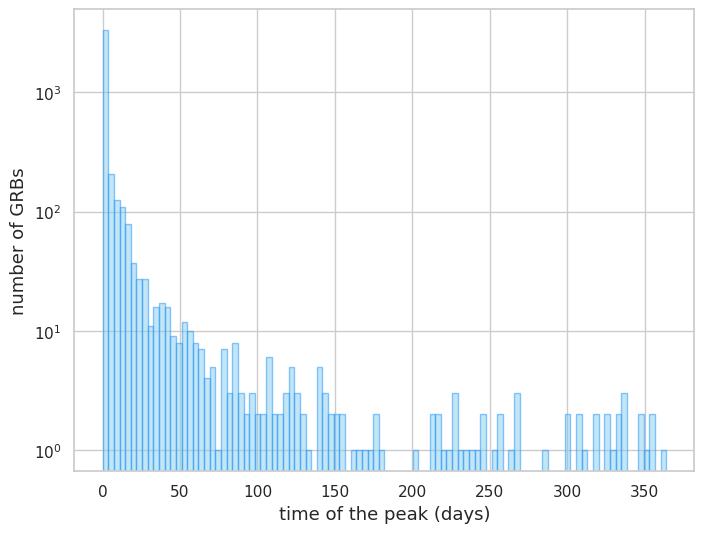

In [49]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 6))

plt.hist(time_max, bins=100, color='skyblue', edgecolor='dodgerblue', alpha=0.5)

plt.xlabel('time of the peak (days)', fontsize=13)
plt.ylabel('number of GRBs', fontsize=13)
plt.yscale('log')

### Duration between the first and the minimal magnitude

In [50]:
# duration between the first detection and the minimal magnitude
Dt = duration_between_first_and_peak(pseudo_obs)

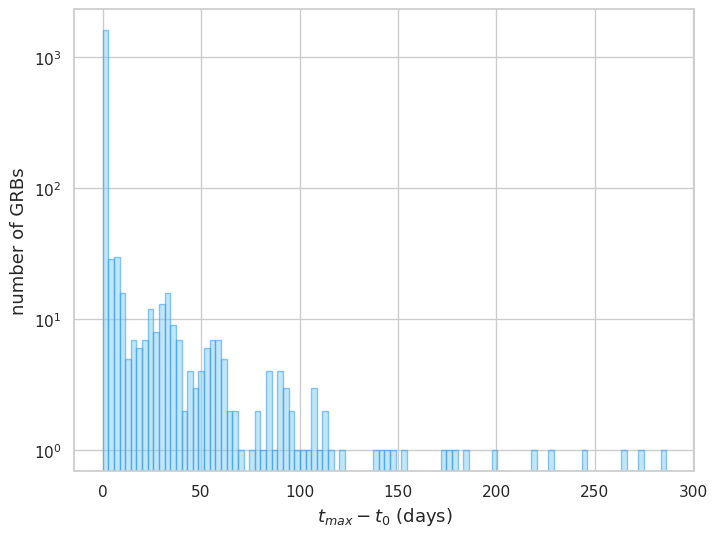

In [51]:
# plot of the duration distribution for the r filter

plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 6))

Dt_not_nan = [x for x in Dt[2] if not math.isnan(x)]    # Dt[2] corresponds to the r filter

plt.hist(Dt_not_nan, bins=100, color='skyblue', edgecolor='dodgerblue', alpha=0.5)

plt.xlabel(r'$t_{max} - t_0$ (days)', fontsize=13)
plt.ylabel('number of GRBs', fontsize=13)
plt.yscale('log')

### Increasing and decreasing rates of the different parts of the light curve

In [52]:
# rates of the increasing and decreasing parts of the light curve
rate_dec_1, rate_dec_3, rate_inc = rate(pseudo_obs)

In [53]:
rate_dec_1_mean = np.nanmean(np.array(rate_dec_1), axis=0)     # mean rate over the filters for each configuration
rate_dec_1_mean_not_nan = rate_dec_1_mean[~np.isnan(rate_dec_1_mean)]    # remove nan values

rate_dec_3_mean = np.nanmean(np.array(rate_dec_3), axis=0)
rate_dec_3_mean_not_nan = rate_dec_3_mean[~np.isnan(rate_dec_3_mean)]

rate_inc_mean = np.nanmean(np.array(rate_inc), axis=0)
rate_inc_mean_not_nan = rate_inc_mean[~np.isnan(rate_inc_mean)]

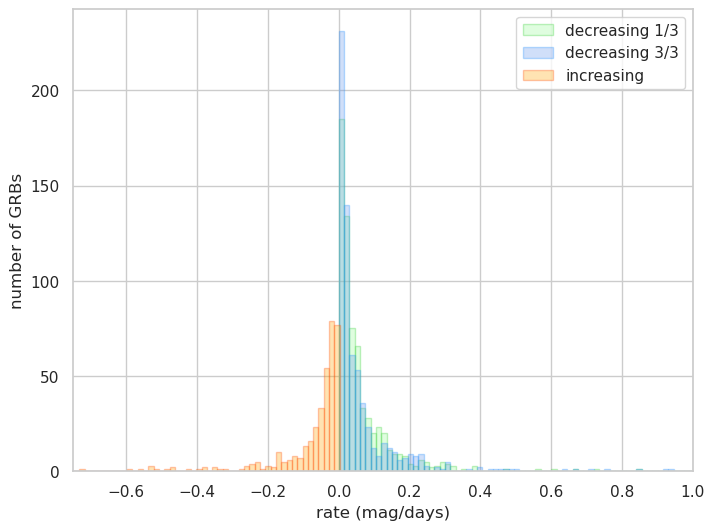

In [54]:
# plot of the mean rates over the filter for each configuration

fig = plt.figure(figsize=(8, 6))

binwidth = 0.015

plt.hist(rate_dec_1_mean, 
         bins=np.arange(min(rate_dec_1_mean_not_nan), max(rate_dec_1_mean_not_nan) + binwidth, binwidth), 
         label='decreasing 1/3', color='palegreen', edgecolor='limegreen', alpha=0.3);

plt.hist(rate_dec_3_mean_not_nan, 
         bins=np.arange(min(rate_dec_3_mean_not_nan), max(rate_dec_3_mean_not_nan) + binwidth, binwidth), 
         label='decreasing 3/3',color='cornflowerblue', edgecolor='dodgerblue', alpha=0.3);

plt.hist(rate_inc_mean_not_nan, 
         bins=np.arange(min(rate_inc_mean_not_nan), max(rate_inc_mean_not_nan) + binwidth, binwidth), 
         label='increasing', color='orange', edgecolor='orangered', alpha=0.3);

plt.xlabel('rate (mag/days)')
plt.ylabel('number of GRBs')
plt.xlim([-0.75, 1])

plt.legend()

### g-r color

In [63]:
# g-r color
color = color(pseudo_obs)

Text(0, 0.5, 'number of GRBs')

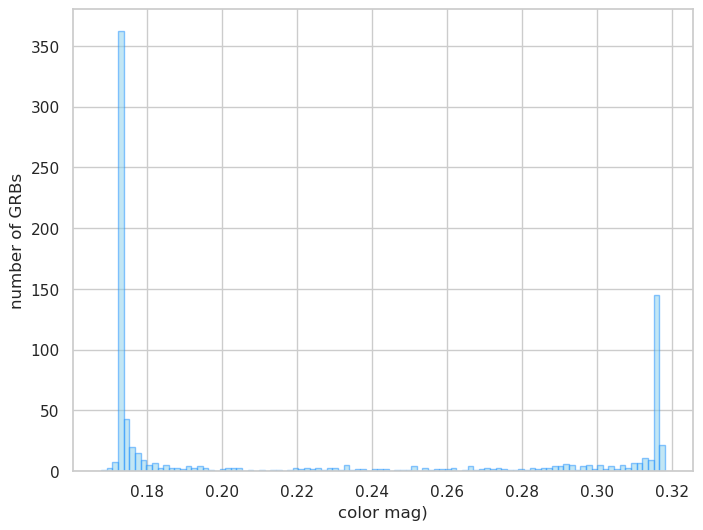

In [64]:
color_not_nan = np.array(color)[~np.isnan(np.array(color))]

fig = plt.figure(figsize=(8,6))

plt.hist(color, bins=100, color='skyblue', edgecolor='dodgerblue', alpha=0.5)

plt.xlabel('color mag)')
plt.ylabel('number of GRBs')

## Correlations matrix between the initial model parameters and the calculated features from pseudo-observations

,E0,n0,z,thetaObs,thetaWing,log10(E0),log10(n0),cos(thetaObs),thetaObs/thetaCore,mag_min,time_max,rate_dec_1,rate_dec_3,rate_inc,color,tmax-t0,log(time_max),log(tmax-t0)
E0,1.000000,-0.115594,-0.603301,0.026766,0.277190,0.975120,-0.123215,-0.048828,0.026766,NaN,0.395612,NaN,NaN,NaN,NaN,NaN,0.216496,NaN
n0,-0.115594,1.000000,0.430677,0.265434,0.007877,-0.127246,0.831652,-0.304258,0.265434,NaN,-0.594628,NaN,NaN,NaN,NaN,NaN,-0.609449,NaN
z,-0.603301,0.430677,1.000000,-0.141976,-0.271702,-0.694403,0.683271,0.150391,-0.141976,NaN,-0.904644,NaN,NaN,NaN,NaN,NaN,-0.840461,NaN
thetaObs,0.026766,0.265434,-0.141976,1.000000,0.914569,-0.070580,0.350137,-0.996245,1.000000,NaN,0.251680,NaN,NaN,NaN,NaN,NaN,0.340483,NaN
thetaWing,0.277190,0.007877,-0.271702,0.914569,1.000000,0.161047,0.217366,-0.914508,0.914569,NaN,0.430619,NaN,NaN,NaN,NaN,NaN,0.453252,NaN
log10(E0),0.975120,-0.127246,-0.694403,-0.070580,0.161047,1.000000,-0.243770,0.044166,-0.070580,NaN,0.471339,NaN,NaN,NaN,NaN,NaN,0.286239,NaN
log10(n0),-0.123215,0.831652,0.683271,0.350137,0.217366,-0.243770,1.000000,-0.379594,0.350137,NaN,-0.714731,NaN,NaN,NaN,NaN,NaN,-0.733525,NaN
cos(thetaObs),-0.048828,-0.304258,0.150391,-0.996245,-0.914508,0.044166,-0.379594,1.000000,-0.996245,NaN,-0.254294,NaN,NaN,NaN,NaN,NaN,-0.326152,NaN
thetaObs/thetaCore,0.026766,0.265434,-0.141976,1.000000,0.914569,-0.070580,0.350137,-0.996245,1.000000,NaN,0.251680,NaN,NaN,NaN,NaN,NaN,0.340483,NaN
mag_min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


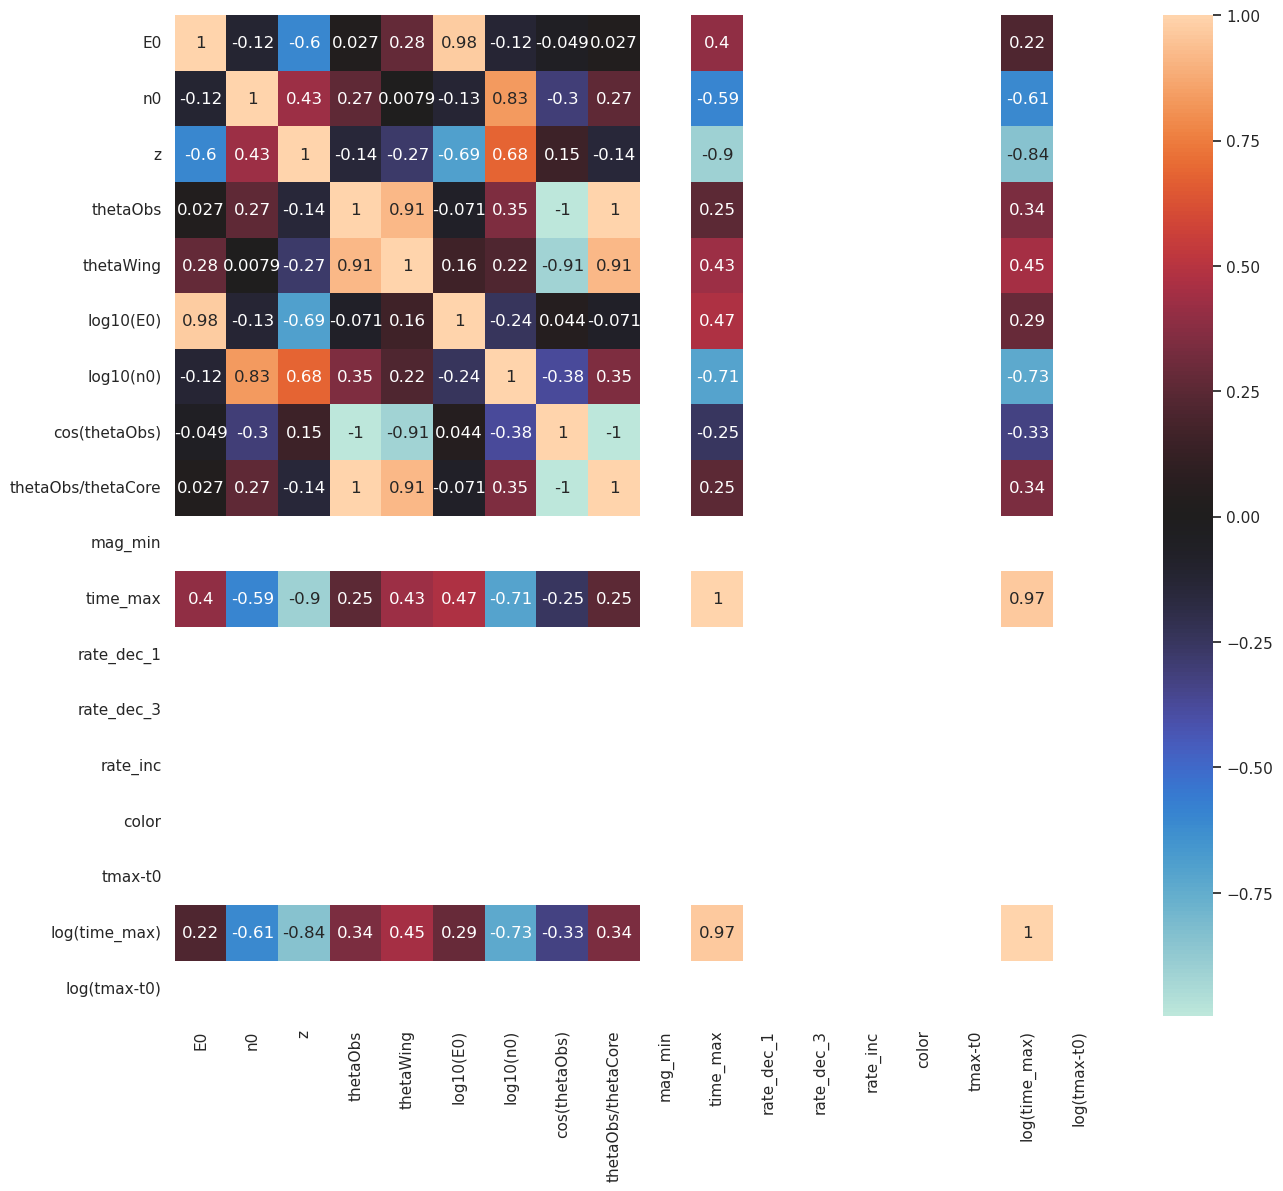

In [31]:
heatmap(pseudo_obs, mag_min, time_max, rate_dec_1, rate_dec_3, rate_inc, color, Dt, 'all')